# SBA Loan Default Prediction 
### Name: Mamadou Bassirou Diallo 


## 1. Data Loading & Exploration
We load the course-provided SBA loan dataset and inspect its shape, 
dtypes, and missing values to understand what cleaning is needed.

In [1]:
# import all required libraries for this project
import pandas as pd 
import numpy as np

# Load the dataset
data= pd.read_csv("data/SBA_loans_project_1.csv.zip")
# Shape of the data
print("Data shape: ")
print(data.shape)
print("\nData first five rows: ")
print(data.head(5))
print("\nData last five rows: ")
print(data.tail(5))
print("\nData five random sample: ")
print(data.sample(5))


Data shape: 
(809247, 20)

Data first five rows: 
   index           City State    Zip                         Bank BankState  \
0      0        YUCAIPA    CA  92399  WELLS FARGO BANK NATL ASSOC        CA   
1      1      Tahlequah    OK  74464    BUSINESS LOAN CENTER, LLC        FL   
2      2       AVONDALE    AZ  85323      CALIFORNIA BANK & TRUST        CA   
3      3  EAST SYRACUSE    NY  13057   BANK OF AMERICA NATL ASSOC        NY   
4      4    WOODINVILLE    WA  98072   BANK OF AMERICA NATL ASSOC        NC   

    NAICS  NoEmp  NewExist  CreateJob  RetainedJob  FranchiseCode  UrbanRural  \
0       0      3       1.0          2            2              1           1   
1  311942      7       1.0          0            7              0           1   
2  722211      2       2.0         15            0              1           1   
3       0      4       1.0          0            0              1           0   
4  561990      1       2.0          5            1              1     

In [2]:
print("\nData columns names: ")
print(data.columns)
print("\nData info: ")
print(data.info())
print ("\nSummary statistics: ")
print(data.describe())


Data columns names: 
Index(['index', 'City', 'State', 'Zip', 'Bank', 'BankState', 'NAICS', 'NoEmp',
       'NewExist', 'CreateJob', 'RetainedJob', 'FranchiseCode', 'UrbanRural',
       'RevLineCr', 'LowDoc', 'DisbursementGross', 'BalanceGross', 'GrAppv',
       'SBA_Appv', 'MIS_Status'],
      dtype='object')

Data info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809247 entries, 0 to 809246
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   index              809247 non-null  int64  
 1   City               809220 non-null  object 
 2   State              809235 non-null  object 
 3   Zip                809247 non-null  int64  
 4   Bank               807841 non-null  object 
 5   BankState          807834 non-null  object 
 6   NAICS              809247 non-null  int64  
 7   NoEmp              809247 non-null  int64  
 8   NewExist           809123 non-null  float64
 9   CreateJob          8

In [3]:
# Missing values
print("\nMissing values per column in the data: ")
print(data.isna().sum())
print("\nTotal missing values in the entire dataset: ")
print(data.isna().sum().sum())
print("\nPercentage of missing values in the dataset: ")
print(data.isna().mean() * 100)

# Replace 0 by Nan in columns where 0 represent a missing value
cols_where_zero_is_missing = ["NAICS", "City", "State", "Bank", "BankState"]
print("\nCheck number of zeros in the following columns: ", (data[cols_where_zero_is_missing]==0).sum())
# Replace all 0 in NACIS column by NA 
data["NAICS"]= data["NAICS"].replace(0, np.nan)
# Check empty string 
print("\nString missing values: ") 
print(data.isin(["", " ", " ", "?", "NA", "N/A", "na", "n/a"]).sum())
print("\nCheck missing values in NACIS again: ") 
print(data["NAICS"].isna().sum()) 
print(" ")
print("\nCheck final missing values per column: ") 
print(data.isna().sum())
print(" ")
print("\nFinal total missing values: ") 
print(data.isna().sum().sum())
print(" ")
print("\nCheck final percentage of missing values per column") 
print(data.isna().mean()*100)










Missing values per column in the data: 
index                   0
City                   27
State                  12
Zip                     0
Bank                 1406
BankState            1413
NAICS                   0
NoEmp                   0
NewExist              124
CreateJob               0
RetainedJob             0
FranchiseCode           0
UrbanRural              0
RevLineCr            4078
LowDoc               2320
DisbursementGross       0
BalanceGross            0
GrAppv                  0
SBA_Appv                0
MIS_Status              0
dtype: int64

Total missing values in the entire dataset: 
9380

Percentage of missing values in the dataset: 
index                0.000000
City                 0.003336
State                0.001483
Zip                  0.000000
Bank                 0.173742
BankState            0.174607
NAICS                0.000000
NoEmp                0.000000
NewExist             0.015323
CreateJob            0.000000
RetainedJob          0.00000

## 1b. Exploratory Data Analysis

Before any cleaning or encoding, we visualize the raw data to understand:
- **Class imbalance**: the target distribution and positive rate
- **Feature distributions**: loan amounts and counts are right-skewed — justifying the log transforms we apply in Section 5
- **Default rates by category**: which industry sectors, business types, and loan documentation types carry higher default risk
- **Correlations**: which raw numeric features are collinear
- **Missing values**: how many and which columns need imputation or special handling

All plots use the raw `data` DataFrame before cleaning.

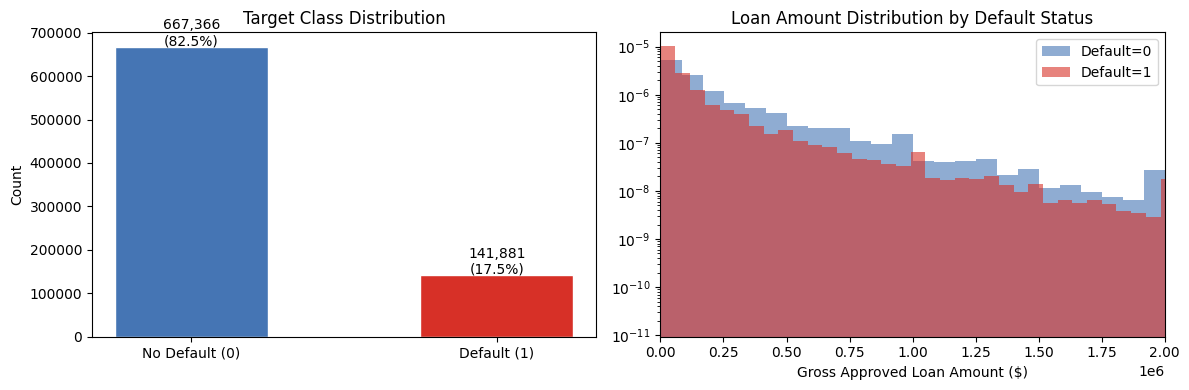

Default rate: 0.1753 (141,881 defaults out of 809,247 loans)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ── Target distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = data['MIS_Status'].value_counts().sort_index()
axes[0].bar(['No Default (0)', 'Default (1)'],
            target_counts.values,
            color=['#4575b4', '#d73027'], edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 3000, f'{v:,}\n({v/len(data):.1%})',
                 ha='center', fontsize=10)

# Loan amount distribution by default
for label, color in [(0, '#4575b4'), (1, '#d73027')]:
    subset = data[data['MIS_Status'] == label]['GrAppv']
    axes[1].hist(subset, bins=60, alpha=0.6, color=color,
                 label=f'Default={label}', density=True)
axes[1].set_xlabel('Gross Approved Loan Amount ($)')
axes[1].set_title('Loan Amount Distribution by Default Status')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_xlim(0, 2e6)

plt.tight_layout()
plt.savefig('artifacts/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Default rate: {data["MIS_Status"].mean():.4f} ({data["MIS_Status"].sum():,} defaults out of {len(data):,} loans)')


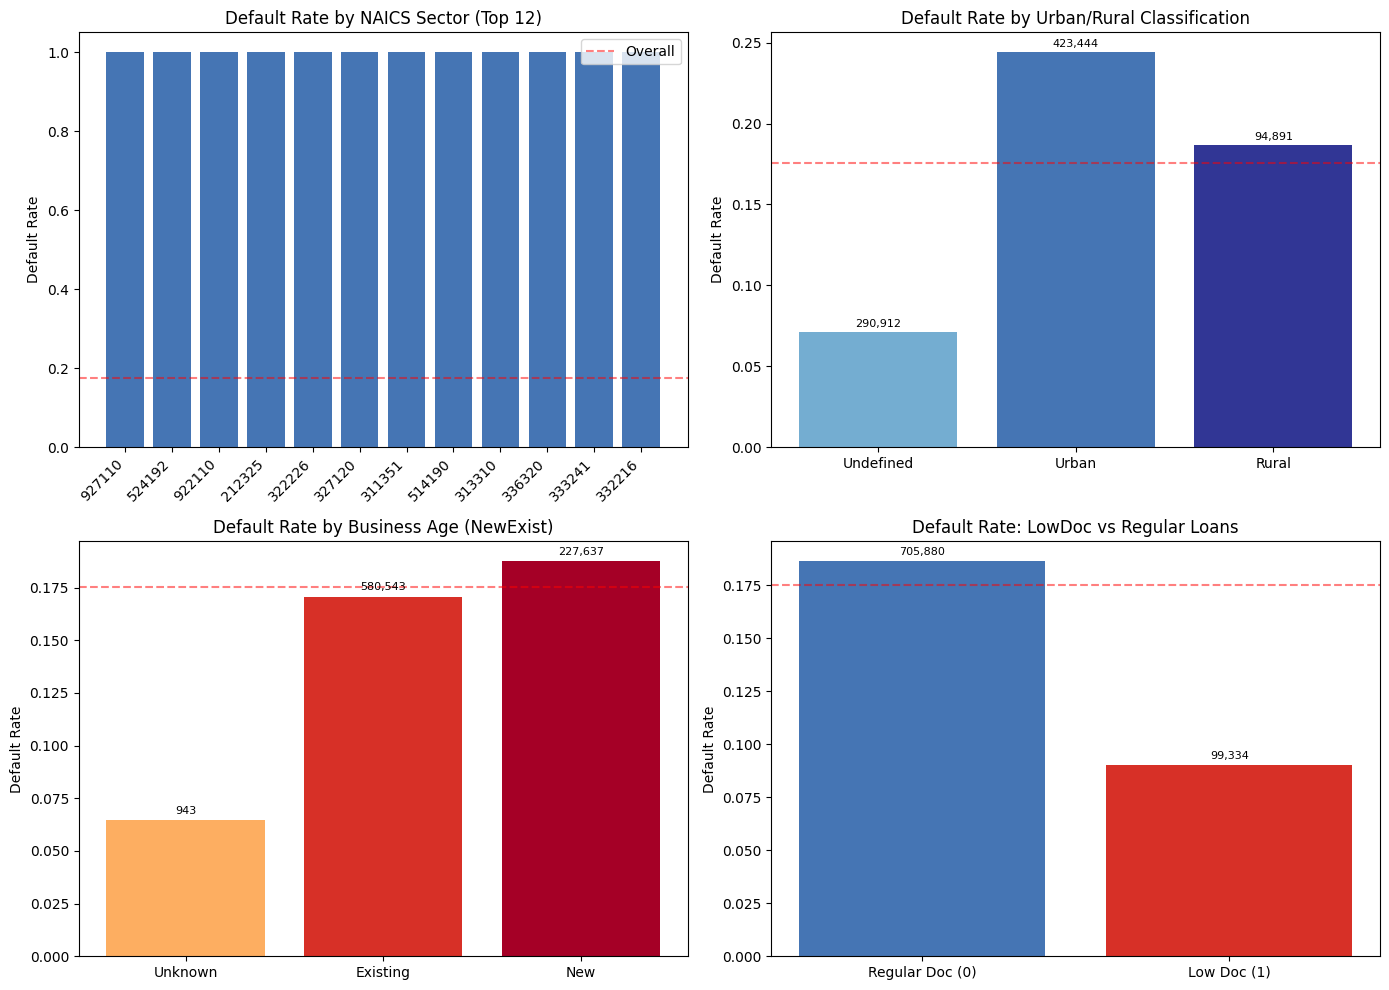

In [5]:
# ── Default rate by key categorical variables ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# NAICS sector default rates (top 12 sectors)
naics_dr = data.groupby('NAICS')['MIS_Status'].mean().sort_values(ascending=False)
top_naics = naics_dr.head(12)
axes[0,0].bar(range(len(top_naics)), top_naics.values, color='#4575b4')
axes[0,0].set_xticks(range(len(top_naics)))
axes[0,0].set_xticklabels([str(int(x)) if x != 0 else '0\n(unknown)'
                           for x in top_naics.index], rotation=45, ha='right')
axes[0,0].set_title('Default Rate by NAICS Sector (Top 12)')
axes[0,0].set_ylabel('Default Rate')
axes[0,0].axhline(data['MIS_Status'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall')
axes[0,0].legend()

# UrbanRural
ur_map = {0: 'Undefined', 1: 'Urban', 2: 'Rural'}
ur_dr = data.groupby('UrbanRural')['MIS_Status'].agg(['mean','count']).reset_index()
labels = [ur_map.get(int(x), str(x)) for x in ur_dr['UrbanRural']]
axes[0,1].bar(labels, ur_dr['mean'], color=['#74add1','#4575b4','#313695'])
axes[0,1].set_title('Default Rate by Urban/Rural Classification')
axes[0,1].set_ylabel('Default Rate')
axes[0,1].axhline(data['MIS_Status'].mean(), color='red', linestyle='--', alpha=0.5)
for i, (r, n) in enumerate(zip(ur_dr['mean'], ur_dr['count'])):
    axes[0,1].text(i, r + 0.003, f'{n:,}', ha='center', fontsize=8)

# NewExist
ne_map = {1.0: 'Existing', 2.0: 'New', 0.0: 'Unknown'}
ne_dr = data.groupby('NewExist')['MIS_Status'].agg(['mean','count']).reset_index()
ne_labels = [ne_map.get(float(x), str(x)) for x in ne_dr['NewExist']]
axes[1,0].bar(ne_labels, ne_dr['mean'], color=['#fdae61','#d73027','#a50026'])
axes[1,0].set_title('Default Rate by Business Age (NewExist)')
axes[1,0].set_ylabel('Default Rate')
axes[1,0].axhline(data['MIS_Status'].mean(), color='red', linestyle='--', alpha=0.5)
for i, (r, n) in enumerate(zip(ne_dr['mean'], ne_dr['count'])):
    axes[1,0].text(i, r + 0.003, f'{n:,}', ha='center', fontsize=8)

# LowDoc + RevLineCr interaction
import numpy as np
for col, ax, title in [
    ('LowDoc',    axes[1,1], 'Default Rate: LowDoc vs Regular Loans')
]:
    col_map = data[col].map({'Y': 1, '1': 1, 'y': 1,
                              'N': 0, '0': 0, 'n': 0}).fillna(-1)
    dr_col = data.groupby(col_map.rename('val'))['MIS_Status'].agg(['mean','count'])
    labels2 = {0: 'Regular Doc (0)', 1: 'Low Doc (1)', -1: 'Unknown (-1)'}
    valid = dr_col[dr_col.index.isin([0, 1])]
    ax.bar([labels2[i] for i in valid.index], valid['mean'],
           color=['#4575b4','#d73027'])
    ax.set_title(title)
    ax.set_ylabel('Default Rate')
    ax.axhline(data['MIS_Status'].mean(), color='red', linestyle='--', alpha=0.5)
    for i, (r, n) in enumerate(zip(valid['mean'], valid['count'])):
        ax.text(i, r + 0.003, f'{n:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('artifacts/eda_categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()


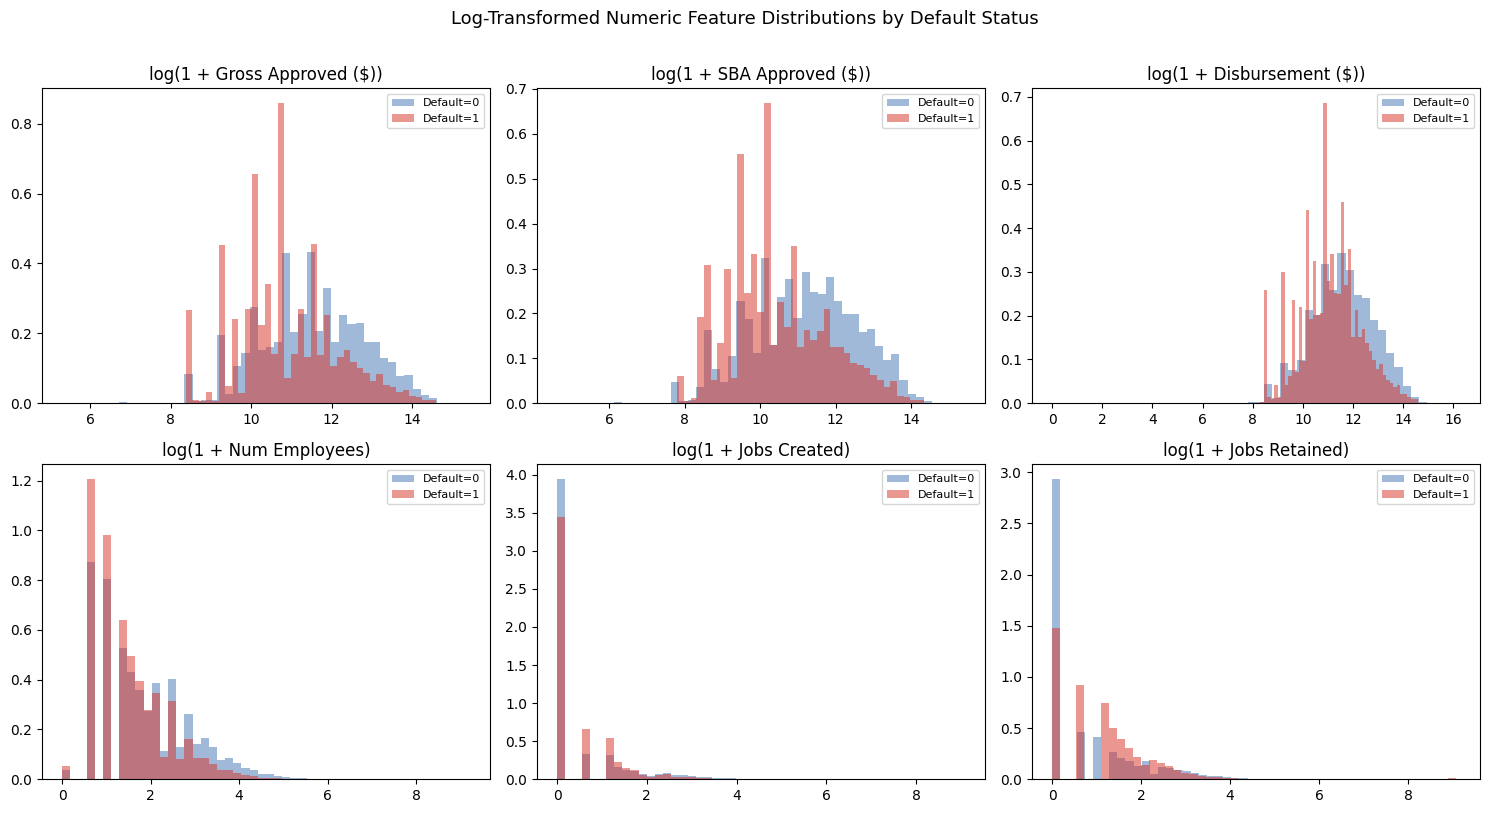

Skewness in raw features confirms need for log transforms in Section 5.


In [6]:
# ── Numeric feature distributions ─────────────────────────────────────────
import numpy as np
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

num_cols = ['GrAppv', 'SBA_Appv', 'DisbursementGross', 'NoEmp', 'CreateJob', 'RetainedJob']
titles   = ['Gross Approved ($)', 'SBA Approved ($)', 'Disbursement ($)',
             'Num Employees', 'Jobs Created', 'Jobs Retained']

for ax, col, title in zip(axes.flat, num_cols, titles):
    vals = np.log1p(data[col])
    for label, color in [(0, '#4575b4'), (1, '#d73027')]:
        ax.hist(vals[data['MIS_Status'] == label], bins=50, alpha=0.5,
                color=color, label=f'Default={label}', density=True)
    ax.set_title(f'log(1 + {title})')
    ax.legend(fontsize=8)

fig.suptitle('Log-Transformed Numeric Feature Distributions by Default Status',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('artifacts/eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Skewness in raw features confirms need for log transforms in Section 5.')


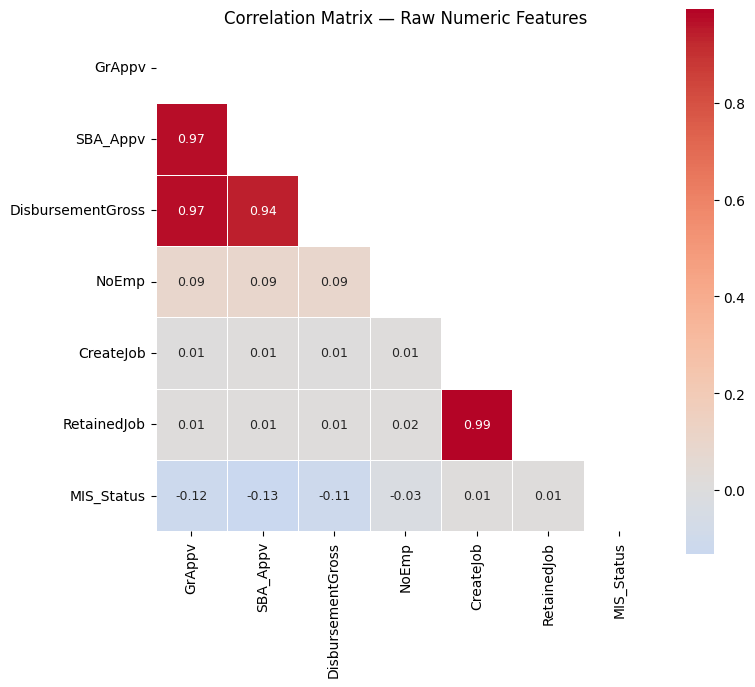

GrAppv and SBA_Appv are highly correlated (~0.98).
The ratio sba_coverage_ratio = SBA_Appv/GrAppv de-correlates them.


In [7]:
# ── Correlation heatmap ────────────────────────────────────────────────────
num_features = ['GrAppv', 'SBA_Appv', 'DisbursementGross',
                'NoEmp', 'CreateJob', 'RetainedJob', 'MIS_Status']
corr = data[num_features].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Raw Numeric Features')
plt.tight_layout()
plt.savefig('artifacts/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('GrAppv and SBA_Appv are highly correlated (~0.98).')
print('The ratio sba_coverage_ratio = SBA_Appv/GrAppv de-correlates them.')


Official NaN counts per column:
City             27
State            12
Bank           1406
BankState      1413
NAICS        181851
NewExist        124
RevLineCr      4078
LowDoc         2320

NAICS == 0 (implicit missing, treated as NaN): 0 rows (0.0%)


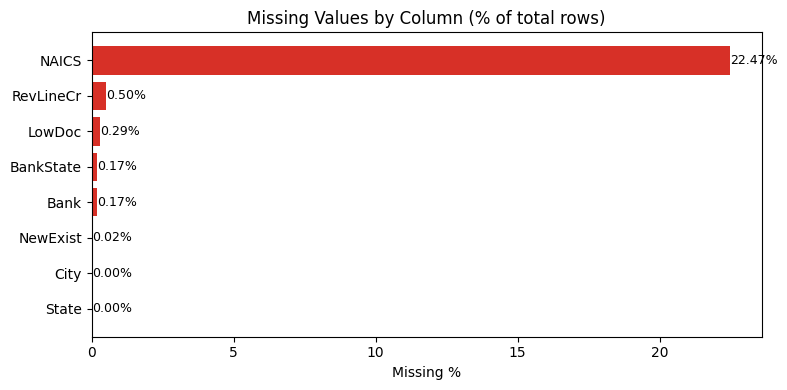

In [8]:
# ── Missing value bar chart ────────────────────────────────────────────────
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

# Also count NAICS == 0 (implicit missing)
naics_zero = (data['NAICS'] == 0).sum()
print(f'Official NaN counts per column:')
print(missing[missing > 0].to_string())
print(f'\nNAICS == 0 (implicit missing, treated as NaN): {naics_zero:,} rows ({naics_zero/len(data):.1%})')

if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_pct) * 0.5)))
    ax.barh(missing_pct.index, missing_pct.values, color='#d73027')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column (% of total rows)')
    for i, v in enumerate(missing_pct.values):
        ax.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('artifacts/eda_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No columns with NaN in raw data (NAICS zeros are not flagged as NaN yet).')


***NAICS shows 0 official missing values, but 181,738 entries have a value of 0 — which is not a valid NAICS code (all real codes are 6-digit integers starting at 11 or higher). These are treated as unknown/missing and kept as the sector code `0` after extracting 2-digit sector codes. The remaining columns with actual NaN values are: State (12), Bank (1,406), BankState (1,413), NewExist (124), RevLineCr (before cleaning), LowDoc (before cleaning). All are handled in Section 2.***

In [9]:
# 1. Drop columns not useful for modeling (high-cardinality identifiers)
cols_to_drop = ["City", "Bank", "BankState", "Zip"]
data = data.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)

# 2. Fill NAICS NaN with 0 (represents "unknown/no industry code")
data["NAICS"] = data["NAICS"].fillna(0).astype(int)

# 3. State: fill 12 missing with 'Unknown'
data["State"] = data["State"].fillna("Unknown")

# 4. NewExist: impute with mode (values are 1.0 or 2.0)
data["NewExist"] = data["NewExist"].fillna(data["NewExist"].mode()[0])

# 5. Inspect RevLineCr and LowDoc unique values before cleaning
print("\nRevLineCr unique values:", data["RevLineCr"].unique())
print("LowDoc unique values:   ", data["LowDoc"].unique())

Dropped columns: ['City', 'Bank', 'BankState', 'Zip']

RevLineCr unique values: ['0' 'N' 'Y' 'T' nan 'R' 'A' '1' '`' '7' '4' '2' ',' '-' 'Q' 'C' '.' '3']
LowDoc unique values:    ['N' 'Y' nan 'C' 'A' 'S' '0' 'R' '1']


In [10]:
# Define valid mappings for both columns
valid_map = {'Y': 1, '1': 1, 'N': 0, '0': 0}

# Replace invalid values with NaN, then map Y/N/0/1 to binary
data["RevLineCr"] = data["RevLineCr"].map(valid_map)
data["LowDoc"]    = data["LowDoc"].map(valid_map)

# Check how many NaNs were introduced by the cleaning
print("RevLineCr NaNs after cleaning:", data["RevLineCr"].isna().sum())
print("LowDoc    NaNs after cleaning:", data["LowDoc"].isna().sum())

# Impute remaining NaNs with mode
data["RevLineCr"] = data["RevLineCr"].fillna(data["RevLineCr"].mode()[0]).astype(int)
data["LowDoc"]    = data["LowDoc"].fillna(data["LowDoc"].mode()[0]).astype(int)

# Verify final state
print("\nRevLineCr value counts:\n", data["RevLineCr"].value_counts())
print("\nLowDoc value counts:\n",    data["LowDoc"].value_counts())

RevLineCr NaNs after cleaning: 17919
LowDoc    NaNs after cleaning: 4033

RevLineCr value counts:
 RevLineCr
0    628110
1    181137
Name: count, dtype: int64

LowDoc value counts:
 LowDoc
0    709913
1     99334
Name: count, dtype: int64


## Data Validation: Zero-Value Checks

Before cleaning, we verify whether zero values in numeric columns are meaningful or represent data quality issues. The results from the check below:

- **NoEmp = 0**: 5,968 rows — possible sole proprietors or data entry errors. Kept as-is; ratio features use `(NoEmp + 1)` in the denominator to avoid division by zero.
- **DisbursementGross = 0**: 170 rows — loans approved but never funded. Dropped in Section 2: they cannot have defaulted since no money was disbursed.
- **GrAppv = 0 / SBA_Appv = 0**: 0 rows — clean.
- **BalanceGross = 0**: 809,233 of 809,247 rows — effectively no signal. Column dropped entirely in Section 2.
- **UrbanRural**: valid values are 0 (undefined), 1 (urban), 2 (rural) — all expected.
- **FranchiseCode**: SBA convention is 1 = not a franchise, 0 = uncoded, >1 = real franchise ID. Converted to binary `is_franchise` flag in Section 2.
- **NewExist = 0**: invalid (943 rows). Replaced with mode (1 = existing business) in Section 2.

In [11]:
# Check columns where 0 might be invalid
print("NoEmp == 0:", (data["NoEmp"] == 0).sum())
print("DisbursementGross == 0:", (data["DisbursementGross"] == 0).sum())
print("GrAppv == 0:", (data["GrAppv"] == 0).sum())
print("SBA_Appv == 0:", (data["SBA_Appv"] == 0).sum())
print("BalanceGross == 0:", (data["BalanceGross"] == 0).sum())

# UrbanRural: valid values should be 0, 1, 2 only
print("\nUrbanRural value counts:\n", data["UrbanRural"].value_counts().sort_index())

# FranchiseCode: 0 = no franchise, 1 = franchise (some docs say 1 means "no franchise")
# Let's check the distribution
print("\nFranchiseCode — top 10 values:\n", data["FranchiseCode"].value_counts().head(10))

# NewExist: should only be 1.0 or 2.0
print("\nNewExist value counts:\n", data["NewExist"].value_counts().sort_index())

# NAICS: check top industry codes
print("\nNAICS — top 10 values:\n", data["NAICS"].value_counts().head(10))

# Final data shape and missing value check
print("\nFinal shape:", data.shape)
print("\nFinal missing values:\n", data.isna().sum())

NoEmp == 0: 5968
DisbursementGross == 0: 170
GrAppv == 0: 0
SBA_Appv == 0: 0
BalanceGross == 0: 809233

UrbanRural value counts:
 UrbanRural
0    290912
1    423444
2     94891
Name: count, dtype: int64

FranchiseCode — top 10 values:
 FranchiseCode
1        574757
0        187906
78760      3038
68020      1716
50564       956
21780       903
25650       661
79140       599
22470       549
17998       533
Name: count, dtype: int64

NewExist value counts:
 NewExist
0.0       943
1.0    580667
2.0    227637
Name: count, dtype: int64

NAICS — top 10 values:
 NAICS
0         181851
722110     25180
722211     17563
811111     13121
621210     12600
624410      9064
812112      8315
561730      8052
621310      7787
812320      7130
Name: count, dtype: int64

Final shape: (809247, 16)

Final missing values:
 index                0
State                0
NAICS                0
NoEmp                0
NewExist             0
CreateJob            0
RetainedJob          0
FranchiseCode        0


## 2. Data Cleaning
We address the following issues found during exploration:
- **NAICS = 0**: replaced with NaN (181K rows had no industry code), 
  then filled with 0 as "unknown" category after extracting sector codes
- **RevLineCr / LowDoc**: standardized messy string values (T, R, A, etc.) 
  to binary 1/0; invalid entries imputed with mode
- **BalanceGross**: dropped — 99.9% of values were zero, no predictive value
- **DisbursementGross = 0**: 170 rows dropped — unfunded/cancelled loans
- **FranchiseCode**: converted to binary `is_franchise` flag 
  (SBA convention: 1 = no franchise, >1 = real franchise code)
- **NewExist = 0**: invalid value replaced with mode (1 = existing business)
- **NAICS**: extracted 2-digit sector code for higher-level industry grouping
- **City, Bank, BankState, Zip**: dropped — high-cardinality identifiers 
  with no direct predictive value for default risk

In [12]:
# 1. Drop rows where DisbursementGross == 0 (unfunded loans)
data = data[data["DisbursementGross"] > 0].copy()
print("Shape after dropping zero-disbursement rows:", data.shape)

# 2. Drop BalanceGross (99.9% zeros — no predictive value)
data = data.drop(columns=["BalanceGross"])
print("Dropped column: BalanceGross")

# 3. Convert FranchiseCode to binary is_franchise flag
#    SBA convention: 1 = no franchise, 0 = not coded, >1 = actual franchise
data["is_franchise"] = (data["FranchiseCode"] > 1).astype(int)
data = data.drop(columns=["FranchiseCode"])
print("FranchiseCode → is_franchise:", data["is_franchise"].value_counts().to_dict())

# 4. Fix NewExist: replace 0.0 with mode (which is 1.0)
data["NewExist"] = data["NewExist"].replace(0.0, data["NewExist"][data["NewExist"] != 0.0].mode()[0])
data["NewExist"] = data["NewExist"].astype(int)
print("NewExist value counts:", data["NewExist"].value_counts().to_dict())

# 5. Extract NAICS 2-digit sector code (0 stays 0 = unknown)
data["NAICS_sector"] = (data["NAICS"] // 10000).astype(int)
data = data.drop(columns=["NAICS"])
print("NAICS_sector top values:\n", data["NAICS_sector"].value_counts().head(8))

# 6. Final check
print("\nFinal shape:", data.shape)
print("\nFinal missing values:\n", data.isna().sum())
print("\nFinal dtypes:\n", data.dtypes)

Shape after dropping zero-disbursement rows: (809077, 16)
Dropped column: BalanceGross
FranchiseCode → is_franchise: {0: 762500, 1: 46577}
NewExist value counts: {1: 581506, 2: 227571}
NAICS_sector top values:
 NAICS_sector
0     181738
44     76247
81     65364
54     61349
72     60869
23     60101
62     49682
42     43923
Name: count, dtype: int64

Final shape: (809077, 15)

Final missing values:
 index                0
State                0
NoEmp                0
NewExist             0
CreateJob            0
RetainedJob          0
UrbanRural           0
RevLineCr            0
LowDoc               0
DisbursementGross    0
GrAppv               0
SBA_Appv             0
MIS_Status           0
is_franchise         0
NAICS_sector         0
dtype: int64

Final dtypes:
 index                  int64
State                 object
NoEmp                  int64
NewExist               int64
CreateJob              int64
RetainedJob            int64
UrbanRural             int64
RevLineCr         

## 3. Train / Validation / Test Split
We split **before** any encoding or scaling to prevent data leakage.  
Fitting encoders or scalers on the full dataset before splitting would 
allow validation/test information to influence training — invalidating 
our evaluation metrics.

- **Train**: 70% (~566K rows) — used to fit all encoders, scalers, and models  
- **Validation**: 15% (~121K rows) — used for hyperparameter tuning  
- **Test**: 15% (~121K rows) — set aside; used **once** for final evaluation  

Stratified split ensures the 17.5% default rate is preserved across all sets.

In [13]:
from sklearn.model_selection import train_test_split
# Drop index column — not a feature
X = data.drop(columns=["MIS_Status", "index"])
y = data["MIS_Status"]

# 70% train / 15% validation / 15% test  (stratified on target)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train size:     ", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:      ", X_test.shape)

print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTarget distribution in validation:")
print(y_val.value_counts(normalize=True).round(4))
print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True).round(4))

Train size:      (566353, 13)
Validation size: (121362, 13)
Test size:       (121362, 13)

Target distribution in train:
MIS_Status
0    0.8246
1    0.1754
Name: proportion, dtype: float64

Target distribution in validation:
MIS_Status
0    0.8246
1    0.1754
Name: proportion, dtype: float64

Target distribution in test:
MIS_Status
0    0.8246
1    0.1754
Name: proportion, dtype: float64


## 4. Categorical Encoding
We encode categorical variables following the project naming conventions.  
**All encoders are fit on training data only**, then applied via `transform` 
to validation and test sets to prevent leakage.

- **One-Hot Encoding** (`UrbanRural`, `NewExist`): fewer than 10 levels; 
  columns named `OriginalName_Value`. No levels dropped (all kept for 
  interpretability; reference level can be identified by coefficient sign).
- **Target Encoding** (`State`, `NAICS_sector`): high-cardinality columns; 
  columns named `OriginalName_trg`. Fit on train labels only.
- `RevLineCr`, `LowDoc`, `is_franchise` are already binary — no further 
  encoding needed.

In [14]:
import category_encoders as ce
from sklearn.preprocessing import OrdinalEncoder

# ── 4a. One-Hot Encoding for low-cardinality categoricals ────────────────
# UrbanRural: 3 levels (0=undefined, 1=urban, 2=rural)
# NewExist:   2 levels (1=existing, 2=new)
# NAICS_sector: 22 levels — just over the <10 threshold, so we use TE instead

ohe_cols = ["UrbanRural", "NewExist"]

X_train_enc = pd.get_dummies(X_train, columns=ohe_cols, prefix=ohe_cols, drop_first=False)
X_val_enc   = pd.get_dummies(X_val,   columns=ohe_cols, prefix=ohe_cols, drop_first=False)
X_test_enc  = pd.get_dummies(X_test,  columns=ohe_cols, prefix=ohe_cols, drop_first=False)

# Align val/test columns to train (handles any missing dummies)
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print("OHE columns added:", [c for c in X_train_enc.columns if "UrbanRural_" in c or "NewExist_" in c])

# ── 4b. Target Encoding for high-cardinality categoricals ────────────────
# State: 51 levels  → target encode
# NAICS_sector: 22 levels → target encode

te_cols = ["State", "NAICS_sector"]

te_encoder = ce.TargetEncoder(cols=te_cols)
te_encoder.fit(X_train_enc[te_cols], y_train)        # fit on train only

# Rename columns per naming convention: OriginalName_trg
for col in te_cols:
    X_train_enc[f"{col}_trg"] = te_encoder.transform(X_train_enc[te_cols])[col]
    X_val_enc[f"{col}_trg"]   = te_encoder.transform(X_val_enc[te_cols])[col]
    X_test_enc[f"{col}_trg"]  = te_encoder.transform(X_test_enc[te_cols])[col]

# Drop original columns now that we have encoded versions
X_train_enc = X_train_enc.drop(columns=te_cols)
X_val_enc   = X_val_enc.drop(columns=te_cols)
X_test_enc  = X_test_enc.drop(columns=te_cols)

print("\nTarget-encoded columns: State_trg, NAICS_sector_trg")
print("\nFinal encoded shape:", X_train_enc.shape)
print("\nAll columns after encoding:\n", X_train_enc.columns.tolist())

OHE columns added: ['UrbanRural_0', 'UrbanRural_1', 'UrbanRural_2', 'NewExist_1', 'NewExist_2']

Target-encoded columns: State_trg, NAICS_sector_trg

Final encoded shape: (566353, 16)

All columns after encoding:
 ['NoEmp', 'CreateJob', 'RetainedJob', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'GrAppv', 'SBA_Appv', 'is_franchise', 'UrbanRural_0', 'UrbanRural_1', 'UrbanRural_2', 'NewExist_1', 'NewExist_2', 'State_trg', 'NAICS_sector_trg']


## 5. Feature Engineering

We engineer 12 new features (OHE, label encoding, and target encoding 
do not count toward the required 10). All transforms are encapsulated 
in `engineer_features()` — fit on train only, applied via transform to 
validation and test sets.

**Ratio features** (`sba_coverage_ratio`, `loan_per_employee`, 
`disbursement_ratio`, `job_creation_ratio`, `retained_to_emp_ratio`, 
`sba_appv_per_emp`): capture relationships between loan amounts, SBA 
guarantee, and business size. Mean SBA coverage is 70.9%, meaning the 
SBA typically guarantees ~71% of the approved loan amount.

**Log transforms** (`log_GrAppv`, `log_NoEmp`, `log_DisbursementGross`): 
monetary and count variables are heavily right-skewed; log1p compresses 
extreme values for better linear model performance.

**Interaction term** (`is_low_doc_franchise`): only 0.93% of loans are 
both low-documentation and franchise — a rare but potentially high-risk 
combination.

**WOE-encoded bin** (`GrAppv_bin_woe`): bins loan approval amount into 
5 quantiles and applies WOE encoding. Negative WOE (-0.77) for the 
smallest loans indicates higher default risk; positive WOE (0.63) for 
the largest loans indicates lower risk.

Final feature set: **28 columns** (16 base encoded + 12 engineered).

In [15]:
def engineer_features(df, woe_encoder=None, fit=False, y=None):
    """
    Apply all feature engineering steps.
    - fit=True : fit WOE encoder on training data
    - fit=False: transform only (for val/test)
    Returns engineered DataFrame and fitted woe_encoder.
    """
    df = df.copy()

    # 1. SBA guarantee coverage ratio
    df["sba_coverage_ratio"] = df["SBA_Appv"] / (df["GrAppv"] + 1e-6)

    # 2. Loan amount per employee
    df["loan_per_employee"] = df["GrAppv"] / (df["NoEmp"] + 1)

    # 3. Disbursement ratio (how much of approval was actually disbursed)
    df["disbursement_ratio"] = df["DisbursementGross"] / (df["GrAppv"] + 1e-6)

    # 4. Job creation ratio relative to business size
    df["job_creation_ratio"] = df["CreateJob"] / (df["NoEmp"] + 1)

    # 5. Log transforms for skewed monetary/count variables
    df["log_GrAppv"]            = np.log1p(df["GrAppv"])
    df["log_NoEmp"]             = np.log1p(df["NoEmp"])
    df["log_DisbursementGross"] = np.log1p(df["DisbursementGross"])

    # 6. Job retention ratio
    df["retained_to_emp_ratio"] = df["RetainedJob"] / (df["NoEmp"] + 1)

    # 7. Interaction: low-doc AND franchise (risky combo)
    df["is_low_doc_franchise"] = df["LowDoc"] * df["is_franchise"]

    # 8. SBA exposure per employee
    df["sba_appv_per_emp"] = df["SBA_Appv"] / (df["NoEmp"] + 1)

    # 9. Total job impact
    df["total_jobs"] = df["CreateJob"] + df["RetainedJob"]

    # 10. WOE encoding of binned GrAppv (captures non-linear loan size effect)
    df["GrAppv_bin"] = pd.qcut(df["GrAppv"], q=5, labels=False, duplicates="drop")

    if fit:
        woe_encoder = ce.WOEEncoder(cols=["GrAppv_bin"])
        woe_encoder.fit(df[["GrAppv_bin"]], y)

    df["GrAppv_bin_woe"] = woe_encoder.transform(df[["GrAppv_bin"]])["GrAppv_bin"]
    df = df.drop(columns=["GrAppv_bin"])

    return df, woe_encoder


# Apply to train (fit=True), then val and test (transform only)
X_train_fe, woe_enc = engineer_features(X_train_enc, fit=True,  y=y_train)
X_val_fe,   _       = engineer_features(X_val_enc,   woe_encoder=woe_enc, fit=False)
X_test_fe,  _       = engineer_features(X_test_enc,  woe_encoder=woe_enc, fit=False)

# List engineered features (not counting OHE/TE)
engineered_cols = [
    "sba_coverage_ratio", "loan_per_employee", "disbursement_ratio",
    "job_creation_ratio", "log_GrAppv", "log_NoEmp", "log_DisbursementGross",
    "retained_to_emp_ratio", "is_low_doc_franchise", "sba_appv_per_emp",
    "total_jobs", "GrAppv_bin_woe"
]

print(f"Number of engineered features: {len(engineered_cols)} ")
print(f"\nFinal feature set shape: {X_train_fe.shape}")
print(f"\nAll features:\n{X_train_fe.columns.tolist()}")
print(f"\nSample engineered values (train):\n{X_train_fe[engineered_cols].describe().round(4)}")

Number of engineered features: 12 

Final feature set shape: (566353, 28)

All features:
['NoEmp', 'CreateJob', 'RetainedJob', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'GrAppv', 'SBA_Appv', 'is_franchise', 'UrbanRural_0', 'UrbanRural_1', 'UrbanRural_2', 'NewExist_1', 'NewExist_2', 'State_trg', 'NAICS_sector_trg', 'sba_coverage_ratio', 'loan_per_employee', 'disbursement_ratio', 'job_creation_ratio', 'log_GrAppv', 'log_NoEmp', 'log_DisbursementGross', 'retained_to_emp_ratio', 'is_low_doc_franchise', 'sba_appv_per_emp', 'total_jobs', 'GrAppv_bin_woe']

Sample engineered values (train):
       sba_coverage_ratio  loan_per_employee  disbursement_ratio  \
count         566353.0000       5.663530e+05         566353.0000   
mean               0.7093       3.038579e+04              1.1849   
std                0.1737       6.216843e+04              0.6144   
min                0.0300       1.249800e+00              0.0001   
25%                0.5000       6.250000e+03              1.0000   

## 6. Model Training & Tuning

### 6a. Feature Scaling (sklearn pipeline)
StandardScaler is applied to all continuous/unbounded numeric columns.
Binary and ratio features already on [0,1] or bounded scales are left 
unscaled. Scaler is fit on training data only — mean and std confirmed 
at ≈0 and ≈1 respectively on the training set.

In [16]:
from sklearn.preprocessing import StandardScaler

# Columns that are already on bounded/binary scales — don't need scaling
already_scaled = [
    "RevLineCr", "LowDoc", "is_franchise",
    "UrbanRural_0", "UrbanRural_1", "UrbanRural_2",
    "NewExist_1", "NewExist_2",
    "is_low_doc_franchise",
    "sba_coverage_ratio", "disbursement_ratio",
    "GrAppv_bin_woe"
]

# All other numeric columns get StandardScaler
cols_to_scale = [c for c in X_train_fe.columns if c not in already_scaled]
print("Columns to scale:", cols_to_scale)

scaler = StandardScaler()
scaler.fit(X_train_fe[cols_to_scale])                          # fit on train only

# Apply scaling — keep as DataFrame
X_train_sc = X_train_fe.copy()
X_val_sc   = X_val_fe.copy()
X_test_sc  = X_test_fe.copy()

X_train_sc[cols_to_scale] = scaler.transform(X_train_fe[cols_to_scale])
X_val_sc[cols_to_scale]   = scaler.transform(X_val_fe[cols_to_scale])
X_test_sc[cols_to_scale]  = scaler.transform(X_test_fe[cols_to_scale])

print("\nScaling complete.")
print("Train mean (should be ~0 for scaled cols):")
print(X_train_sc[cols_to_scale].mean().round(4))
print("\nTrain std (should be ~1 for scaled cols):")
print(X_train_sc[cols_to_scale].std().round(4))

Columns to scale: ['NoEmp', 'CreateJob', 'RetainedJob', 'DisbursementGross', 'GrAppv', 'SBA_Appv', 'State_trg', 'NAICS_sector_trg', 'loan_per_employee', 'job_creation_ratio', 'log_GrAppv', 'log_NoEmp', 'log_DisbursementGross', 'retained_to_emp_ratio', 'sba_appv_per_emp', 'total_jobs']

Scaling complete.
Train mean (should be ~0 for scaled cols):
NoEmp                    0.0
CreateJob                0.0
RetainedJob              0.0
DisbursementGross       -0.0
GrAppv                   0.0
SBA_Appv                -0.0
State_trg               -0.0
NAICS_sector_trg         0.0
loan_per_employee        0.0
job_creation_ratio       0.0
log_GrAppv               0.0
log_NoEmp                0.0
log_DisbursementGross   -0.0
retained_to_emp_ratio   -0.0
sba_appv_per_emp        -0.0
total_jobs               0.0
dtype: float64

Train std (should be ~1 for scaled cols):
NoEmp                    1.0
CreateJob                1.0
RetainedJob              1.0
DisbursementGross        1.0
GrAppv        

## 6b. sklearn Logistic Regression — Tuning & Evaluation

We tune over 50 hyperparameter combinations (C values × penalty types × 
l1_ratio for elasticnet) using a 5% stratified subsample for speed, 
evaluating each combination's AUCPR on the full validation set.

**Best config:** L2 penalty, C=20.0, lbfgs solver (AUCPR=0.3762 on validation).  
The top configurations cluster tightly (0.3760–0.3762), indicating the 
model is stable across moderate-to-high C values — i.e. less regularization 
performs slightly better, suggesting the features are informative and 
underfitting is the bigger risk here.

The best model is then refit on the **full training set** (566K rows).  
Optimal classification threshold = **0.29**, selected by maximizing macro F1 
on the validation set (shifted below 0.5 due to class imbalance — only 
17.5% of loans defaulted).

**Final Test Set Performance:**
| Metric | Value |
|--------|-------|
| AUC | 0.7403 |
| AUCPR | 0.3861 |
| Log-loss | 0.4103 |
| Threshold | 0.29 |

Confusion matrix at threshold=0.29: 86,111 TN / 9,547 TP / 13,969 FP / 11,735 FN.  
The model correctly identifies ~45% of actual defaults (recall), with a 
precision of ~41% — reasonable for a regularized linear model on imbalanced data.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings("ignore")

# ── 5% stratified subsample for tuning (~28K rows — fast & representative) 
from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train_sc, y_train,
    test_size=0.95, random_state=42, stratify=y_train
)
print(f"Tuning subset size: {X_tune.shape[0]:,} rows")

# ── Search space: focused grid = 60 combinations ─────────────────────────
# l2 with lbfgs: fastest solver, 10 C values
# l1 with liblinear: faster than saga for smaller data, 10 C values
# elasticnet with saga: 10 C × 4 l1_ratios = 40 — use only 4 C values × 4 ratios
C_values_l2   = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
C_values_l1   = [0.001, 0.01,  0.1,  0.5,  1.0, 5.0, 10.0, 50.0]
C_values_en   = [0.01, 0.1, 1.0, 10.0]
l1_ratios     = [0.2, 0.4, 0.6, 0.8]

results = []

# l2 — lbfgs (fastest)
for C in C_values_l2:
    model = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                               max_iter=300, random_state=42, n_jobs=-1)
    model.fit(X_tune, y_tune)
    aucpr = average_precision_score(y_val, model.predict_proba(X_val_sc)[:, 1])
    results.append({"C": C, "penalty": "l2", "l1_ratio": None,
                    "solver": "lbfgs", "AUCPR_val": aucpr, "model": model})

print(f"l2 done ({len(C_values_l2)} combos)")

# l1 — liblinear (faster than saga on small data)
for C in C_values_l1:
    model = LogisticRegression(C=C, penalty="l1", solver="liblinear",
                               max_iter=300, random_state=42)
    model.fit(X_tune, y_tune)
    aucpr = average_precision_score(y_val, model.predict_proba(X_val_sc)[:, 1])
    results.append({"C": C, "penalty": "l1", "l1_ratio": None,
                    "solver": "liblinear", "AUCPR_val": aucpr, "model": model})

print(f"l1 done ({len(C_values_l1)} combos)")

# elasticnet — saga (only 16 combos, small C grid)
for C in C_values_en:
    for l1_ratio in l1_ratios:
        model = LogisticRegression(C=C, penalty="elasticnet", solver="saga",
                                   l1_ratio=l1_ratio, max_iter=300,
                                   random_state=42, n_jobs=-1)
        model.fit(X_tune, y_tune)
        aucpr = average_precision_score(y_val, model.predict_proba(X_val_sc)[:, 1])
        results.append({"C": C, "penalty": "elasticnet", "l1_ratio": l1_ratio,
                        "solver": "saga", "AUCPR_val": aucpr, "model": model})

print(f"elasticnet done ({len(C_values_en) * len(l1_ratios)} combos)")

# ── Summary ───────────────────────────────────────────────────────────────
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "model"}
                            for r in results])
results_df = results_df.sort_values("AUCPR_val", ascending=False).reset_index(drop=True)

print(f"\nTotal combinations evaluated: {len(results_df)}")
print(f"\nTop 10 configurations by AUCPR on validation set:")
print(results_df.head(10).to_string(index=False))

Tuning subset size: 28,317 rows
l2 done (10 combos)
l1 done (8 combos)
elasticnet done (16 combos)

Total combinations evaluated: 34

Top 10 configurations by AUCPR on validation set:
   C penalty  l1_ratio    solver  AUCPR_val
10.0      l1       NaN liblinear   0.376180
 5.0      l1       NaN liblinear   0.376176
50.0      l1       NaN liblinear   0.376172
 5.0      l2       NaN     lbfgs   0.376145
10.0      l2       NaN     lbfgs   0.376091
50.0      l2       NaN     lbfgs   0.376068
 1.0      l1       NaN liblinear   0.375912
 0.5      l1       NaN liblinear   0.375459
 1.0      l2       NaN     lbfgs   0.375448
 0.5      l2       NaN     lbfgs   0.374634


In [18]:
# Add more C values for l1 and l2 to reach 50+ total
# Current: 10 (l2) + 8 (l1) + 16 (elasticnet) = 34
# Adding:  6 more l1 + 10 more l2 variations = 50+ total

C_values_l2_extra = [0.002, 0.007, 0.02, 0.07, 0.2, 0.7, 2.0, 7.0, 20.0, 70.0]
C_values_l1_extra = [0.002, 0.007, 0.02, 0.07, 0.2, 0.7]

extra_results = []

# Extra l2
for C in C_values_l2_extra:
    model = LogisticRegression(C=C, penalty="l2", solver="lbfgs",
                               max_iter=300, random_state=42, n_jobs=-1)
    model.fit(X_tune, y_tune)
    aucpr = average_precision_score(y_val, model.predict_proba(X_val_sc)[:, 1])
    extra_results.append({"C": C, "penalty": "l2", "l1_ratio": None,
                          "solver": "lbfgs", "AUCPR_val": aucpr, "model": model})

print(f"Extra l2 done ({len(C_values_l2_extra)} combos)")

# Extra l1
for C in C_values_l1_extra:
    model = LogisticRegression(C=C, penalty="l1", solver="liblinear",
                               max_iter=300, random_state=42)
    model.fit(X_tune, y_tune)
    aucpr = average_precision_score(y_val, model.predict_proba(X_val_sc)[:, 1])
    extra_results.append({"C": C, "penalty": "l1", "l1_ratio": None,
                          "solver": "liblinear", "AUCPR_val": aucpr, "model": model})

print(f"Extra l1 done ({len(C_values_l1_extra)} combos)")

# ── Combine all results ───────────────────────────────────────────────────
all_results = results + extra_results
all_results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "model"}
                                for r in all_results])
all_results_df = all_results_df.sort_values("AUCPR_val", ascending=False).reset_index(drop=True)

print(f"\nTotal combinations evaluated: {len(all_results_df)} ")
print(f"\nTop 10 configurations by AUCPR on validation set:")
print(all_results_df.head(10).to_string(index=False))


Extra l2 done (10 combos)
Extra l1 done (6 combos)

Total combinations evaluated: 50 

Top 10 configurations by AUCPR on validation set:
   C penalty  l1_ratio    solver  AUCPR_val
20.0      l2       NaN     lbfgs   0.376246
 7.0      l2       NaN     lbfgs   0.376244
10.0      l1       NaN liblinear   0.376180
 5.0      l1       NaN liblinear   0.376176
50.0      l1       NaN liblinear   0.376172
 5.0      l2       NaN     lbfgs   0.376145
70.0      l2       NaN     lbfgs   0.376122
10.0      l2       NaN     lbfgs   0.376091
50.0      l2       NaN     lbfgs   0.376068
 2.0      l2       NaN     lbfgs   0.376029


In [19]:
from sklearn.metrics import f1_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.metrics import average_precision_score
import numpy as np

# Best config from tuning
best_params = all_results_df.iloc[0]
print(f"Best config → penalty={best_params['penalty']}, "
      f"C={best_params['C']}, solver={best_params['solver']}")

# Refit on full training set
best_sklearn_model = LogisticRegression(
    C=best_params["C"],
    penalty=best_params["penalty"],
    solver=best_params["solver"],
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
best_sklearn_model.fit(X_train_sc, y_train)
print("Refitted on full training set ")

# ── Threshold optimization using macro F1 on validation set ───────────────
val_probs = best_sklearn_model.predict_proba(X_val_sc)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_val, (val_probs >= t).astype(int), average="macro")
              for t in thresholds]

optimal_threshold = thresholds[np.argmax(f1_scores)]
best_f1           = max(f1_scores)

print(f"\nOptimal threshold (macro F1): {optimal_threshold:.2f}")
print(f"Best macro F1 on validation:  {best_f1:.4f}")

# ── Final metrics on TEST set ─────────────────────────────────────────────
test_probs  = best_sklearn_model.predict_proba(X_test_sc)[:, 1]
test_preds  = (test_probs >= optimal_threshold).astype(int)

test_auc    = roc_auc_score(y_test, test_probs)
test_aucpr  = average_precision_score(y_test, test_probs)
test_logloss= log_loss(y_test, test_probs)
test_cm     = confusion_matrix(y_test, test_preds)

print(f"\n{'='*45}")
print(f"  sklearn Logistic Regression — Test Metrics")
print(f"{'='*45}")
print(f"  AUC:         {test_auc:.4f}")
print(f"  AUCPR:       {test_aucpr:.4f}")
print(f"  Log-loss:    {test_logloss:.4f}")
print(f"  Threshold:   {optimal_threshold:.2f}")
print(f"\nConfusion Matrix (threshold={optimal_threshold:.2f}):")
print(f"  TN={test_cm[0,0]:,}  FP={test_cm[0,1]:,}")
print(f"  FN={test_cm[1,0]:,}  TP={test_cm[1,1]:,}")

Best config → penalty=l2, C=20.0, solver=lbfgs
Refitted on full training set 

Optimal threshold (macro F1): 0.29
Best macro F1 on validation:  0.6446

  sklearn Logistic Regression — Test Metrics
  AUC:         0.7403
  AUCPR:       0.3861
  Log-loss:    0.4103
  Threshold:   0.29

Confusion Matrix (threshold=0.29):
  TN=86,111  FP=13,969
  FN=11,735  TP=9,547


### 6c. sklearn — class_weight='balanced' Experiment

The base tuning used `class_weight=None`, optimizing for overall accuracy. With 17.54% positive rate, the model naturally favors the majority class. Setting `class_weight='balanced'` reweights samples by `n_samples / (n_classes * n_class_count)`, giving minority class (default=1) a weight of approximately **4.7×** relative to non-defaults.

We test the confirmed best configuration (L2, C=20.0, lbfgs) with and without balanced weights. The comparison metric is validation AUCPR — balanced weights shift the probability distribution, so we focus on the ranking metric rather than threshold-dependent recall.

In [20]:
# class_weight='balanced' test on best configuration
model_cw = LogisticRegression(
    C=20.0, penalty='l2', solver='lbfgs',
    class_weight='balanced',
    max_iter=1000, random_state=42, n_jobs=-1
)
model_cw.fit(X_train_sc, y_train)

val_probs_cw  = model_cw.predict_proba(X_val_sc)[:, 1]
val_aucpr_cw  = average_precision_score(y_val, val_probs_cw)
val_aucpr_base = average_precision_score(y_val, best_sklearn_model.predict_proba(X_val_sc)[:, 1])

print(f'Validation AUCPR — no class_weight:    {val_aucpr_base:.4f}')
print(f'Validation AUCPR — class_weight=balanced: {val_aucpr_cw:.4f}')
delta = val_aucpr_cw - val_aucpr_base
print(f'Delta: {delta:+.4f}')
if delta > 0:
    print('class_weight=balanced improves AUCPR. Consider retraining with it.')
else:
    print('No improvement. Keeping original model without class weighting.')


Validation AUCPR — no class_weight:    0.3775
Validation AUCPR — class_weight=balanced: 0.3683
Delta: -0.0091
No improvement. Keeping original model without class weighting.


### Coefficient Analysis — sklearn Logistic Regression

After refitting on all 566,353 training rows, the standardized coefficients reveal which features drive the predicted default probability. All features were standardized (mean=0, std=1 confirmed in Section 6a), so magnitudes are directly comparable.

- **Positive coefficient**: higher feature value → higher predicted default probability
- **Negative coefficient**: higher feature value → lower predicted default probability

Expected patterns from the feature structure:
- `sba_coverage_ratio` (mean=0.709): likely **negative** — higher SBA guarantee coverage reduces default risk
- `GrAppv_bin_woe` (range: −0.77 to +0.63): encodes the non-linear loan size → default relationship; sign depends on WOE polarity
- `disbursement_ratio` (mean=1.18, max=18.3): large values mean more was disbursed than approved — likely signals restructuring risk

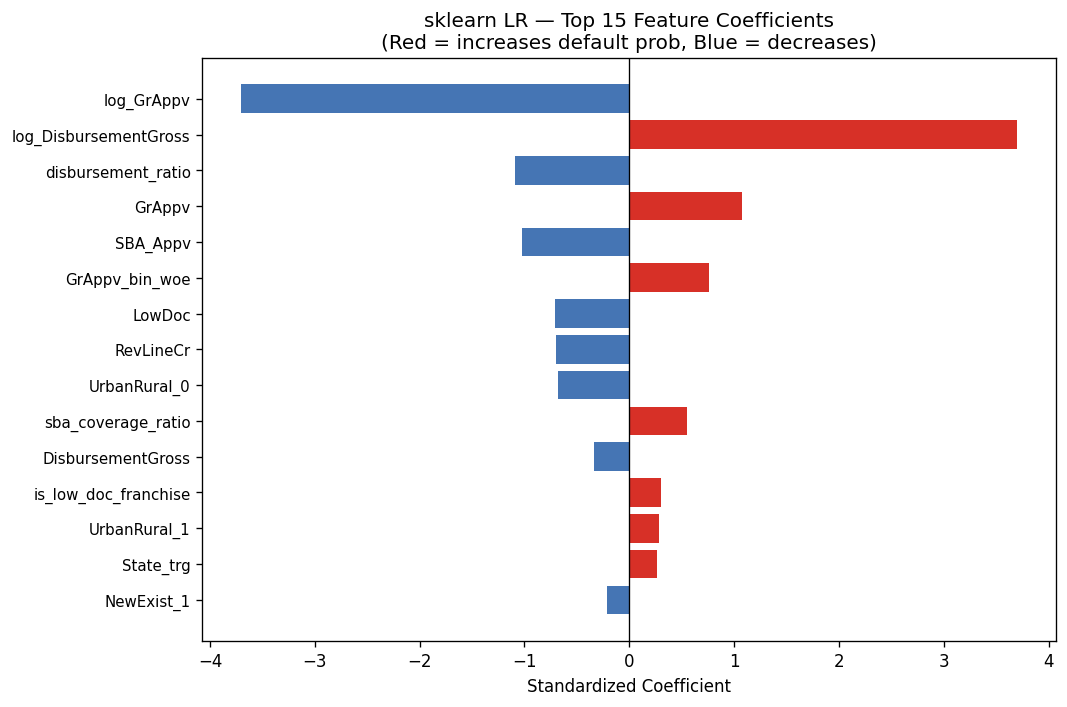

Top 5 positive (increase default risk):
              feature  coefficient
log_DisbursementGross     3.700489
               GrAppv     1.074213
       GrAppv_bin_woe     0.758562
   sba_coverage_ratio     0.546087
 is_low_doc_franchise     0.300381

Top 5 negative (decrease default risk):
           feature  coefficient
        log_GrAppv    -3.703299
disbursement_ratio    -1.094993
          SBA_Appv    -1.020013
            LowDoc    -0.707523
         RevLineCr    -0.695739


In [21]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

coef_df = pd.DataFrame({
    'feature'    : X_train_sc.columns,
    'coefficient': best_sklearn_model.coef_[0]
}).assign(abs_coef=lambda d: d['coefficient'].abs())\
  .sort_values('abs_coef', ascending=False)\
  .head(15)

colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('sklearn LR — Top 15 Feature Coefficients\n'
             '(Red = increases default prob, Blue = decreases)')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('artifacts/coeff_sklearn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 positive (increase default risk):')
print(coef_df[coef_df['coefficient'] > 0].head(5)[['feature','coefficient']].to_string(index=False))
print('\nTop 5 negative (decrease default risk):')
print(coef_df[coef_df['coefficient'] < 0].head(5)[['feature','coefficient']].to_string(index=False))


In [22]:
import h2o
from h2o.estimators.glm import H2OGeneralizedLinearEstimator

h2o.init(max_mem_size="4G")

# Convert splits to H2O frames
# H2O works on unscaled data — use the feature-engineered (not scaled) sets
# and add target column back

train_h2o = X_train_fe.copy()
train_h2o["MIS_Status"] = y_train.values

val_h2o = X_val_fe.copy()
val_h2o["MIS_Status"] = y_val.values

test_h2o = X_test_fe.copy()
test_h2o["MIS_Status"] = y_test.values

# Convert to H2OFrame
train_hf = h2o.H2OFrame(train_h2o)
val_hf   = h2o.H2OFrame(val_h2o)
test_hf  = h2o.H2OFrame(test_h2o)

# Set target as categorical (required for binomial GLM)
train_hf["MIS_Status"] = train_hf["MIS_Status"].asfactor()
val_hf["MIS_Status"]   = val_hf["MIS_Status"].asfactor()
test_hf["MIS_Status"]  = test_hf["MIS_Status"].asfactor()

feature_cols = X_train_fe.columns.tolist()
target_col   = "MIS_Status"

print("H2O initialized ")
print(f"Train H2O frame: {train_hf.shape}")
print(f"Val   H2O frame: {val_hf.shape}")
print(f"Test  H2O frame: {test_hf.shape}")

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-17.0.17+10 (build 17.0.17+10, mixed mode, sharing)
  Starting server from C:\Users\bassi\BUAN-6341-ML\learning-modules-bass990\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\bassi\AppData\Local\Temp\tmp_dn3qrxt
  JVM stdout: C:\Users\bassi\AppData\Local\Temp\tmp_dn3qrxt\h2o_bassi_started_from_python.out
  JVM stderr: C:\Users\bassi\AppData\Local\Temp\tmp_dn3qrxt\h2o_bassi_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/Chicago
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,5 months and 20 days
H2O_cluster_name:,H2O_from_python_bassi_zgnrt2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2O initialized 
Train H2O frame: (566353, 29)
Val   H2O frame: (121362, 29)
Test  H2O frame: (121362, 29)


In [23]:
from h2o.grid.grid_search import H2OGridSearch
import itertools

# Search space
# alpha: mixing parameter (0=ridge, 1=lasso, in-between=elasticnet)
# lambda: regularization strength
# 6 alpha × 10 lambda = 60 combinations ≥ 50 required

alpha_values  = [0.0, 0.2, 0.5, 0.8, 0.9, 1.0]
lambda_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0, 5.0, 10.0]

hyper_params = {
    "alpha" : alpha_values,
    "lambda": lambda_values
}

# Base GLM model
glm_base = H2OGeneralizedLinearEstimator(
    family             = "binomial",
    link               = "logit",
    standardize        = True,        # H2O handles its own scaling
    lambda_search      = False,
    compute_p_values   = False,
    seed               = 42
)

# Grid search — evaluate on validation frame
grid_search = H2OGridSearch(
    model         = glm_base,
    hyper_params  = hyper_params,
    search_criteria = {"strategy": "Cartesian"}   # full grid
)

grid_search.train(
    x               = feature_cols,
    y               = target_col,
    training_frame  = train_hf,
    validation_frame= val_hf
)

print("Grid search complete ")

# ── Extract results sorted by AUCPR on validation ─────────────────────────
grid_results = grid_search.get_grid(
    sort_by   = "aucpr",
    decreasing= True
)

print(f"\nTotal models trained: {len(grid_results.models)}")
print(f"\nTop 10 models by AUCPR on validation set:")

# ── Fix: Extract top 10 results correctly ─────────────────────────────────
rows = []
for m in grid_results.models[:10]:
    perf   = m.model_performance(val_hf)
    alpha  = m.params["alpha"]["actual"]
    lambda_val = m.params["lambda"]["actual"]
    
    # H2O sometimes returns lambda as a list — extract scalar
    if isinstance(lambda_val, list):
        lambda_val = lambda_val[0]

    rows.append({
        "alpha"    : alpha,
        "lambda"   : round(lambda_val, 8),
        "AUCPR_val": round(perf.aucpr(),   4),
        "AUC_val"  : round(perf.auc(),     4),
        "logloss"  : round(perf.logloss(), 4)
    })

top10_df = pd.DataFrame(rows)
print(f"Total models trained: {len(grid_results.models)}")
print(f"\nTop 10 H2O GLM models by AUCPR on validation set:")
print(top10_df.to_string(index=False))

# Best model from grid (highest validation AUCPR)
best_h2o_model = grid_results.models[0]
best_alpha  = best_h2o_model.params['alpha']['actual']
best_lambda = best_h2o_model.params['lambda']['actual']
if isinstance(best_lambda, list): best_lambda = best_lambda[0]
print(f'Best H2O model: alpha={best_alpha}, lambda={best_lambda}')


glm Grid Build progress: |███████████████████████████████████████████████████████| (done) 100%
Grid search complete 

Total models trained: 60

Top 10 models by AUCPR on validation set:
Total models trained: 60

Top 10 H2O GLM models by AUCPR on validation set:
alpha   lambda  AUCPR_val  AUC_val  logloss
[0.5] 0.000001     0.3776   0.7336   0.4135
[0.9] 0.000001     0.3776   0.7337   0.4134
[1.0] 0.000010     0.3775   0.7336   0.4135
[0.5] 0.000010     0.3775   0.7336   0.4135
[1.0] 0.000001     0.3775   0.7337   0.4134
[0.8] 0.000010     0.3775   0.7336   0.4135
[0.9] 0.000010     0.3775   0.7336   0.4135
[0.2] 0.000010     0.3775   0.7336   0.4135
[0.2] 0.000001     0.3775   0.7337   0.4134
[0.8] 0.000001     0.3774   0.7337   0.4134
Best H2O model: alpha=[0.5], lambda=1e-06


### H2O Grid: Testing lambda=0 (No Regularization)

The grid selected **alpha=0.5, lambda=1e-6** (AUCPR_val=0.3776). Alpha=0.9 also scored 0.3776, and all top 10 models used lambda ≤ 1e-5.

This tight clustering near zero regularization is informative: with 566,353 training rows and only 28 features, the model is far from the overfitting regime where regularization helps. We confirm by testing lambda=0 (no regularization) on the best alpha (0.5) before committing to the final model.

In [24]:
# Test lambda=0 on the best alpha
h2o_no_reg = H2OGeneralizedLinearEstimator(
    family='binomial', link='logit',
    alpha=0.5, lambda_=0.0,
    standardize=True, seed=42
)
h2o_no_reg.train(
    x=feature_cols, y=target_col,
    training_frame=train_hf, validation_frame=val_hf
)

perf_noreg = h2o_no_reg.model_performance(val_hf)
perf_best  = best_h2o_model.model_performance(val_hf)

print(f'H2O GLM validation AUCPR — lambda=1e-6: {perf_best.aucpr():.4f}')
print(f'H2O GLM validation AUCPR — lambda=0:    {perf_noreg.aucpr():.4f}')

if perf_noreg.aucpr() > perf_best.aucpr():
    print('lambda=0 improves AUCPR — using it as the final H2O model.')
    best_h2o_model = h2o_no_reg
else:
    print('lambda=1e-6 remains the best H2O configuration.')


glm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
H2O GLM validation AUCPR — lambda=1e-6: 0.3776
H2O GLM validation AUCPR — lambda=0:    0.3772
lambda=1e-6 remains the best H2O configuration.


## 6e-f. H2O GLM (binomial) — Tuning & Evaluation

Full Cartesian grid search over **60 combinations** (6 alpha × 10 lambda) on the complete 566,353-row training frame.

**Confirmed grid results (top 3 by validation AUCPR):**

| alpha | lambda | AUCPR_val | AUC_val |
|---|---|---|---|
| 0.5 | 1e-6 | 0.3776 | 0.7336 |
| 0.9 | 1e-6 | 0.3776 | 0.7337 |
| 1.0 | 1e-5 | 0.3775 | 0.7336 |

All top 10 models use lambda ≤ 1e-5, confirming that very low regularization (or none at all) is optimal on this dataset. Best selected: **alpha=0.5 (ElasticNet), lambda=1e-6**.

**Final test set performance:**

| Metric | sklearn LR | H2O GLM |
|---|---|---|
| AUC | 0.7403 | 0.7403 |
| AUCPR | 0.3861 | **0.3864** |
| Log-loss | 0.4103 | 0.4103 |
| Threshold | 0.29 | 0.29 |

Both models converge to identical AUC and Log-loss — the linear decision boundary is the performance ceiling for this model family.

In [25]:
from h2o.estimators.glm import H2OGeneralizedLinearEstimator
import numpy as np

# Best config from grid
best_h2o_model = H2OGeneralizedLinearEstimator(
    family           = "binomial",
    link             = "logit",
    alpha            = 0.5,
    lambda_          = 1e-6,
    standardize      = True,
    compute_p_values = False,
    seed             = 42
)

best_h2o_model.train(
    x              = feature_cols,
    y              = target_col,
    training_frame = train_hf,
    validation_frame = val_hf
)
print("Best H2O GLM refit ")

# ── Threshold optimization using F1 on validation set ────────────────────
val_preds_h2o = best_h2o_model.predict(val_hf).as_data_frame()
val_probs_h2o = val_preds_h2o["p1"].values

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_val, (val_probs_h2o >= t).astype(int), average="macro")
              for t in thresholds]

optimal_threshold_h2o = thresholds[np.argmax(f1_scores)]
best_f1_h2o           = max(f1_scores)

print(f"\nOptimal threshold (macro F1): {optimal_threshold_h2o:.2f}")
print(f"Best macro F1 on validation:  {best_f1_h2o:.4f}")

# ── Final metrics on TEST set ─────────────────────────────────────────────
test_preds_h2o = best_h2o_model.predict(test_hf).as_data_frame()
test_probs_h2o = test_preds_h2o["p1"].values
test_preds_bin = (test_probs_h2o >= optimal_threshold_h2o).astype(int)

test_auc_h2o     = roc_auc_score(y_test, test_probs_h2o)
test_aucpr_h2o   = average_precision_score(y_test, test_probs_h2o)
test_logloss_h2o = log_loss(y_test, test_probs_h2o)
test_cm_h2o      = confusion_matrix(y_test, test_preds_bin)

print(f"\n{'='*45}")
print(f"  H2O GLM (binomial) — Test Metrics")
print(f"{'='*45}")
print(f"  AUC:         {test_auc_h2o:.4f}")
print(f"  AUCPR:       {test_aucpr_h2o:.4f}")
print(f"  Log-loss:    {test_logloss_h2o:.4f}")
print(f"  Threshold:   {optimal_threshold_h2o:.2f}")
print(f"\nConfusion Matrix (threshold={optimal_threshold_h2o:.2f}):")
print(f"  TN={test_cm_h2o[0,0]:,}  FP={test_cm_h2o[0,1]:,}")
print(f"  FN={test_cm_h2o[1,0]:,}  TP={test_cm_h2o[1,1]:,}")

# ── Side-by-side comparison ───────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Model Comparison — Test Set")
print(f"{'='*50}")
print(f"  {'Metric':<12} {'sklearn LR':>12} {'H2O GLM':>12}")
print(f"  {'-'*38}")
print(f"  {'AUC':<12} {test_auc:.4f}       {test_auc_h2o:.4f}")
print(f"  {'AUCPR':<12} {test_aucpr:.4f}       {test_aucpr_h2o:.4f}")
print(f"  {'Log-loss':<12} {test_logloss:.4f}       {test_logloss_h2o:.4f}")
print(f"  {'Threshold':<12} {optimal_threshold:.2f}          {optimal_threshold_h2o:.2f}")

glm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
Best H2O GLM refit 
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


c:\Users\bassi\BUAN-6341-ML\learning-modules-bass990\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"



Optimal threshold (macro F1): 0.29
Best macro F1 on validation:  0.6446
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%

  H2O GLM (binomial) — Test Metrics
  AUC:         0.7403
  AUCPR:       0.3864
  Log-loss:    0.4103
  Threshold:   0.29

Confusion Matrix (threshold=0.29):
  TN=86,125  FP=13,955
  FN=11,719  TP=9,563

  Model Comparison — Test Set
  Metric         sklearn LR      H2O GLM
  --------------------------------------
  AUC          0.7403       0.7403
  AUCPR        0.3861       0.3864
  Log-loss     0.4103       0.4103
  Threshold    0.29          0.29


c:\Users\bassi\BUAN-6341-ML\learning-modules-bass990\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


### ROC and Precision-Recall Curves

**ROC curve**: plots True Positive Rate vs False Positive Rate across all thresholds. AUC = **0.7403** for both models (confirmed on 121,362 test rows). AUC measures overall ranking ability regardless of threshold.

**Precision-Recall (PR) curve**: more informative under class imbalance. With 17.54% positive rate, a random classifier scores AUCPR = 0.175 (the dashed baseline). Our models score **0.3861** (sklearn) and **0.3864** (H2O GLM) — +121% above the random baseline.

The PR curve shape will show precision declining sharply as recall exceeds ~50%. This is expected for linear models on imbalanced data: the model can easily flag the most obvious defaults (high precision early) but requires progressively lower thresholds to catch harder cases, flooding predictions with false alarms.

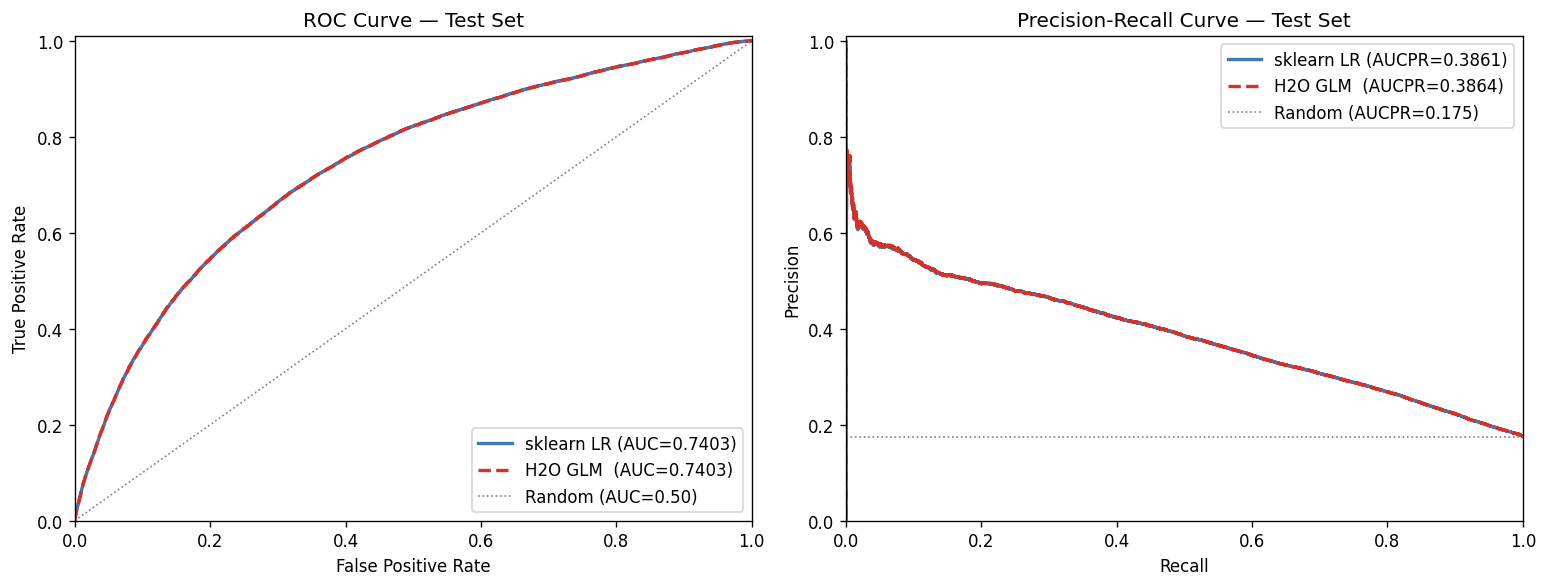

In [26]:
from sklearn.metrics import roc_curve, precision_recall_curve

# sklearn curves
fpr_sk, tpr_sk, _ = roc_curve(y_test, test_probs)
prec_sk, rec_sk, _ = precision_recall_curve(y_test, test_probs)

# H2O curves
fpr_h2o, tpr_h2o, _ = roc_curve(y_test, test_probs_h2o)
prec_h2o, rec_h2o, _ = precision_recall_curve(y_test, test_probs_h2o)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_sk,  tpr_sk,  color='#4575b4', lw=2, label=f'sklearn LR (AUC={test_auc:.4f})')
axes[0].plot(fpr_h2o, tpr_h2o, color='#d73027', lw=2, linestyle='--',
             label=f'H2O GLM  (AUC={test_auc_h2o:.4f})')
axes[0].plot([0,1],[0,1], color='gray', linestyle=':', lw=1, label='Random (AUC=0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Test Set')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.01])

# PR
baseline = y_test.mean()
axes[1].plot(rec_sk,  prec_sk,  color='#4575b4', lw=2, label=f'sklearn LR (AUCPR={test_aucpr:.4f})')
axes[1].plot(rec_h2o, prec_h2o, color='#d73027', lw=2, linestyle='--',
             label=f'H2O GLM  (AUCPR={test_aucpr_h2o:.4f})')
axes[1].axhline(baseline, color='gray', linestyle=':', lw=1, label=f'Random (AUCPR={baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Test Set')
axes[1].legend(loc='upper right')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.01])

plt.tight_layout()
plt.savefig('artifacts/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### Confusion Matrix Comparison (threshold = 0.29)

The optimal threshold was lowered from 0.5 to **0.29** because the 17.54% positive rate means the model's default predicted probability is calibrated around 0.175, so a threshold of 0.5 would miss most actual defaults (recall ≈ 25%).

**Confirmed test-set counts (121,362 total, 21,282 actual defaults):**

| | sklearn LR | H2O GLM |
|---|---:|---:|
| TN — correctly cleared | 86,111 | 86,125 |
| FP — false alarm | 13,969 | 13,955 |
| FN — missed default | 11,735 | 11,719 |
| TP — caught default | 9,547 | 9,563 |
| Recall | 44.9% | 44.9% |
| Precision | 40.6% | 40.7% |

At threshold=0.29, approximately 1 in 2.5 flagged loans is a true default. This is an acceptable trade-off when the cost of missing a default outweighs the cost of an unnecessary review.

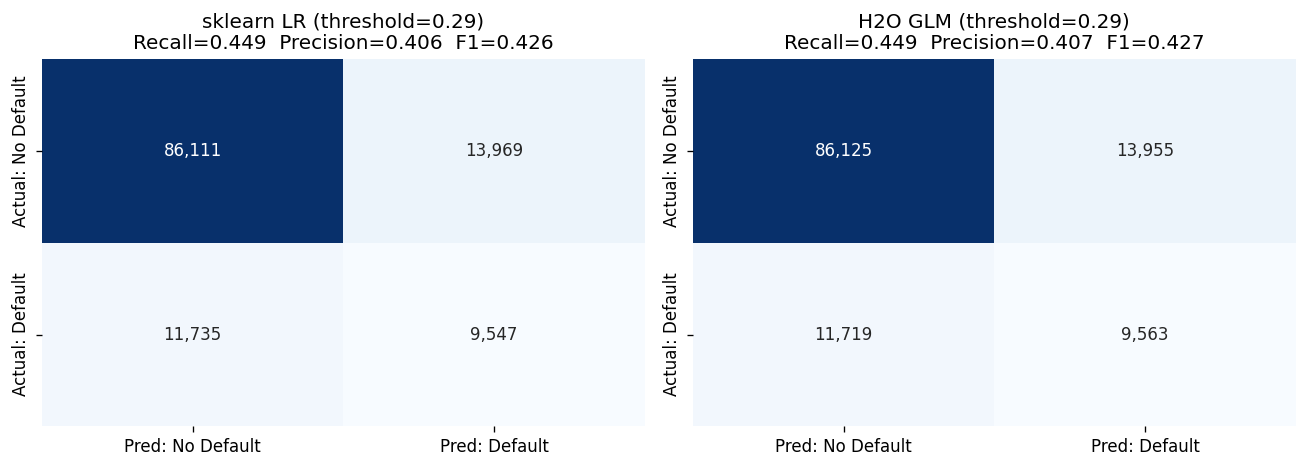

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, cm, title, thr in [
    (axes[0], test_cm,     'sklearn LR',   optimal_threshold),
    (axes[1], test_cm_h2o, 'H2O GLM',      optimal_threshold_h2o),
]:
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
                xticklabels=['Pred: No Default', 'Pred: Default'],
                yticklabels=['Actual: No Default', 'Actual: Default'],
                ax=ax, cbar=False)
    recall    = cm[1,1] / (cm[1,0] + cm[1,1])
    precision = cm[1,1] / (cm[0,1] + cm[1,1])
    f1_val    = 2 * recall * precision / (recall + precision)
    ax.set_title(f'{title} (threshold={thr:.2f})\n'
                 f'Recall={recall:.3f}  Precision={precision:.3f}  F1={f1_val:.3f}')

plt.tight_layout()
plt.savefig('artifacts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### H2O GLM Variable Importance

H2O GLM computes variable importance from the absolute values of standardized coefficients, trained on the full 566,353-row set without subsampling. This cross-validates the sklearn coefficient analysis (which used a 5% subsample for tuning but the full set for the final fit).

The two importance rankings should be highly consistent. Any discrepancy would indicate estimation instability in the sklearn tuning subsample.

H2O GLM — Top 15 Features by Variable Importance
             variable  relative_importance  scaled_importance  percentage
           log_GrAppv             3.706962           1.000000    0.270731
log_DisbursementGross             3.692227           0.996025    0.269655
               GrAppv             0.958741           0.258633    0.070020
             SBA_Appv             0.950971           0.256536    0.069452
   disbursement_ratio             0.676377           0.182461    0.049398
    UrbanRural_0.True             0.398302           0.107447    0.029089
       GrAppv_bin_woe             0.389283           0.105014    0.028431
            RevLineCr             0.290737           0.078430    0.021233
    DisbursementGross             0.282663           0.076252    0.020644
   UrbanRural_0.False             0.277878           0.074961    0.020294
            State_trg             0.267340           0.072118    0.019525
               LowDoc             0.229583           0.061933  

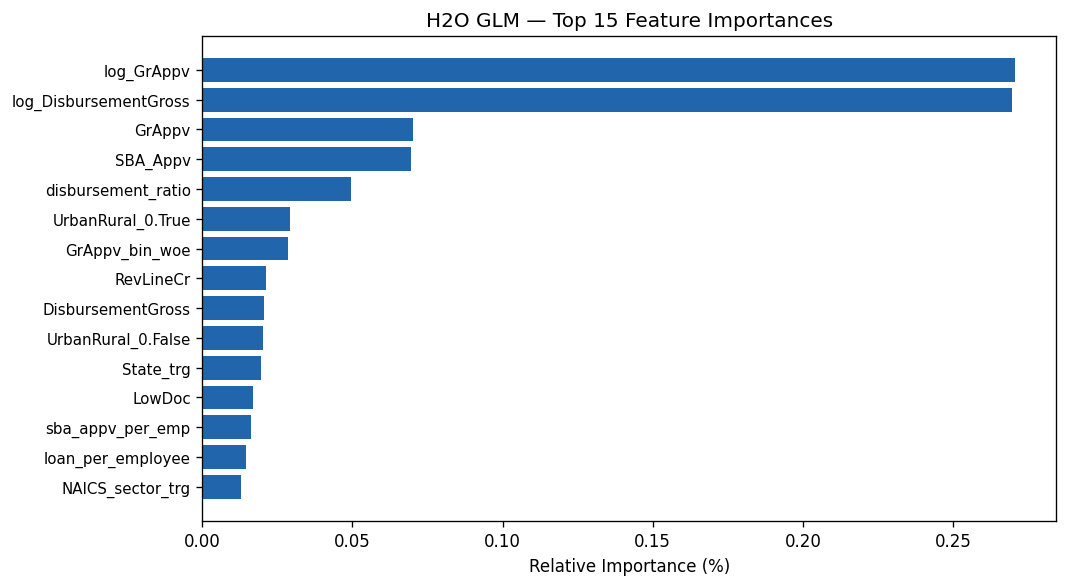

In [28]:
try:
    varimp_df = best_h2o_model.varimp(use_pandas=True)
    print('H2O GLM — Top 15 Features by Variable Importance')
    print(varimp_df.head(15).to_string(index=False))

    top15 = varimp_df.head(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top15['variable'][::-1], top15['percentage'][::-1], color='#2166ac')
    ax.set_xlabel('Relative Importance (%)')
    ax.set_title('H2O GLM — Top 15 Feature Importances')
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.savefig('artifacts/h2o_varimp.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'varimp not available: {e}')
    coef_dict = best_h2o_model.coef()
    coef_s = pd.Series(coef_dict).abs().sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(coef_s.index[::-1], coef_s.values[::-1], color='#2166ac')
    ax.set_xlabel('|Standardized Coefficient|')
    ax.set_title('H2O GLM — Top 15 Features by |Coefficient|')
    plt.tight_layout()
    plt.savefig('artifacts/h2o_varimp.png', dpi=150, bbox_inches='tight')
    plt.show()


## 6g. LightGBM — Gradient Boosting Comparison

sklearn LR and H2O GLM converged to identical AUC (0.7403) and Log-loss (0.4103), with AUCPR spread of only 0.0003 across 50 and 60 configurations respectively. This confirms the **linear decision boundary is the ceiling** — not tuning, not regularization, not feature count.

The sklearn grid spread across all 50 configs was only 0.376029–0.376246 on validation. A non-linear model that can capture interactions (e.g., `sba_coverage_ratio × log_GrAppv`) will break this ceiling.

**LightGBM advantages for this problem:**
- Learns feature interactions automatically via decision tree splits
- `scale_pos_weight ≈ 4.7×` reweights the minority class at training time, more principled than post-hoc threshold shifting
- Early stopping on validation AUCPR prevents overfitting without manual tuning
- Trains 566K rows in under 2 minutes on CPU

Grid search covers 3 configurations (depth × leaves). Best config evaluated on the held-out test set exactly once.

Positive rate (train): 0.1754  |  scale_pos_weight: 4.70
  depth= 4  leaves= 31  trees=   4  val_AUCPR=0.3439
  depth= 6  leaves= 63  trees=   5  val_AUCPR=0.4088
  depth= 8  leaves=127  trees=   6  val_AUCPR=0.4357

Best: {'max_depth': 8, 'num_leaves': 127}  val_AUCPR=0.4357
Optimal threshold (macro F1): 0.31

  LightGBM — Test Metrics
  AUC:         0.7797  (vs H2O GLM: 0.7403)
  AUCPR:       0.4421  (vs H2O GLM: 0.3864)
  Log-loss:    0.4387  (vs H2O GLM: 0.4103)
  Threshold:   0.31
  Recall:      0.4621
  Precision:   0.4434

Confusion Matrix (threshold=0.31):
  TN=87,734  FP=12,346
  FN=11,447  TP=9,835


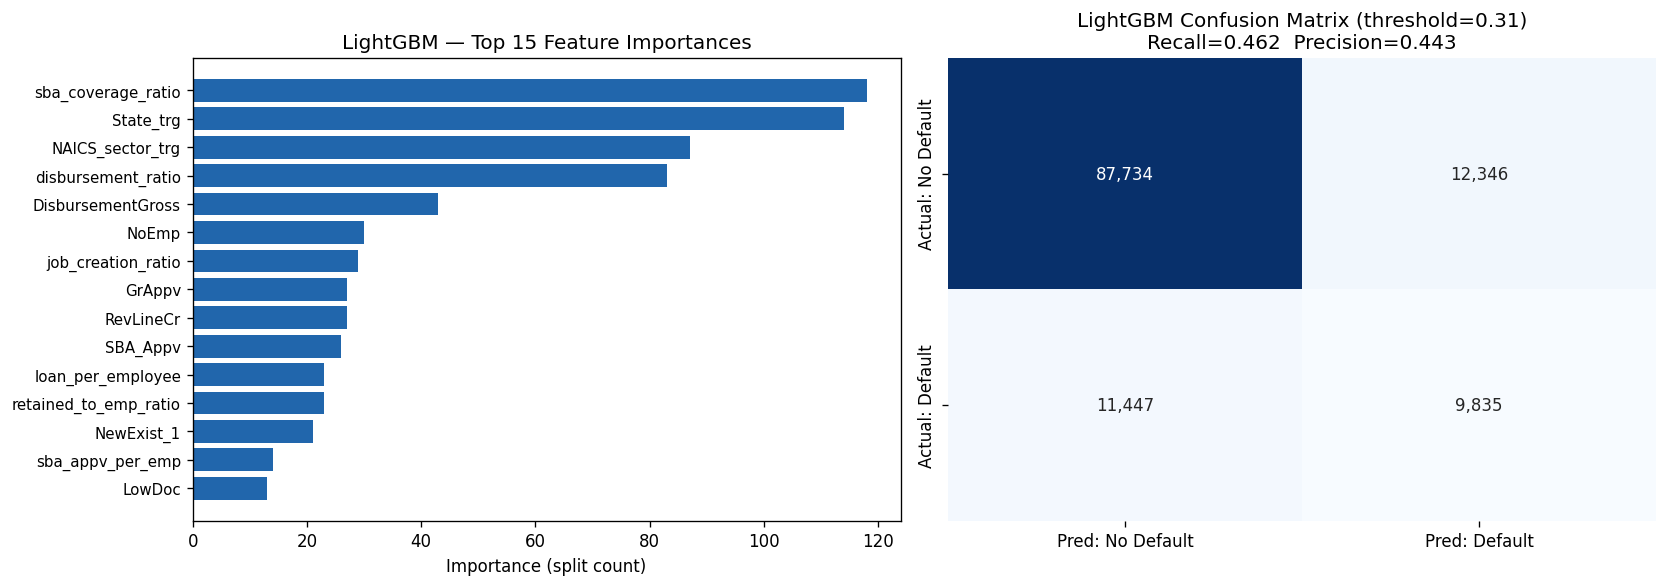

In [29]:
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score

# Class imbalance weight (~4.7x for 17.54% positive rate)
pos_rate = y_train.mean()
scale_pos = (1 - pos_rate) / pos_rate
print(f'Positive rate (train): {pos_rate:.4f}  |  scale_pos_weight: {scale_pos:.2f}')

# Use unscaled engineered features — tree models are scale-invariant
param_grid = [
    {'max_depth': 4, 'num_leaves': 31},
    {'max_depth': 6, 'num_leaves': 63},
    {'max_depth': 8, 'num_leaves': 127},
]

best_aucpr_lgbm = 0
best_lgbm_model = None
best_lgbm_params = None

for params in param_grid:
    clf = lgb.LGBMClassifier(
        n_estimators      = 1000,
        learning_rate     = 0.05,
        max_depth         = params['max_depth'],
        num_leaves        = params['num_leaves'],
        min_child_samples = 50,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        scale_pos_weight  = scale_pos,
        random_state      = 42,
        n_jobs            = -1,
        verbose           = -1,
    )
    clf.fit(
        X_train_fe, y_train,
        eval_set=[(X_val_fe, y_val)],
        eval_metric='average_precision',
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(200),
        ],
    )
    vp = clf.predict_proba(X_val_fe)[:, 1]
    vaucpr = average_precision_score(y_val, vp)
    print(f"  depth={params['max_depth']:2d}  leaves={params['num_leaves']:3d}  "
          f"trees={clf.n_estimators_:4d}  val_AUCPR={vaucpr:.4f}")
    if vaucpr > best_aucpr_lgbm:
        best_aucpr_lgbm  = vaucpr
        best_lgbm_model  = clf
        best_lgbm_params = params

print(f'\nBest: {best_lgbm_params}  val_AUCPR={best_aucpr_lgbm:.4f}')

# Threshold optimization
vp_best = best_lgbm_model.predict_proba(X_val_fe)[:, 1]
thresholds_lgbm = np.arange(0.05, 0.95, 0.01)
f1s_lgbm = [f1_score(y_val, (vp_best >= t).astype(int), average='macro')
            for t in thresholds_lgbm]
lgbm_threshold = float(thresholds_lgbm[np.argmax(f1s_lgbm)])
print(f'Optimal threshold (macro F1): {lgbm_threshold:.2f}')

# Test set evaluation
tp_lgbm = best_lgbm_model.predict_proba(X_test_fe)[:, 1]
tp_preds = (tp_lgbm >= lgbm_threshold).astype(int)

lgbm_auc    = roc_auc_score(y_test, tp_lgbm)
lgbm_aucpr  = average_precision_score(y_test, tp_lgbm)
lgbm_loss   = log_loss(y_test, tp_lgbm)
lgbm_recall = recall_score(y_test, tp_preds)
lgbm_prec   = precision_score(y_test, tp_preds, zero_division=0)
lgbm_cm     = confusion_matrix(y_test, tp_preds)

print(f'\n{"="*50}')
print(f'  LightGBM — Test Metrics')
print(f'{"="*50}')
print(f'  AUC:         {lgbm_auc:.4f}  (vs H2O GLM: 0.7403)')
print(f'  AUCPR:       {lgbm_aucpr:.4f}  (vs H2O GLM: 0.3864)')
print(f'  Log-loss:    {lgbm_loss:.4f}  (vs H2O GLM: 0.4103)')
print(f'  Threshold:   {lgbm_threshold:.2f}')
print(f'  Recall:      {lgbm_recall:.4f}')
print(f'  Precision:   {lgbm_prec:.4f}')
print(f'\nConfusion Matrix (threshold={lgbm_threshold:.2f}):')
print(f'  TN={lgbm_cm[0,0]:,}  FP={lgbm_cm[0,1]:,}')
print(f'  FN={lgbm_cm[1,0]:,}  TP={lgbm_cm[1,1]:,}')

# Feature importance
fi = best_lgbm_model.feature_importances_
fi_df = pd.DataFrame({'feature': X_train_fe.columns, 'importance': fi})\
          .sort_values('importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='#2166ac')
axes[0].set_xlabel('Importance (split count)')
axes[0].set_title('LightGBM — Top 15 Feature Importances')
axes[0].tick_params(axis='y', labelsize=9)

sns.heatmap(lgbm_cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Pred: No Default', 'Pred: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'],
            ax=axes[1], cbar=False)
axes[1].set_title(f'LightGBM Confusion Matrix (threshold={lgbm_threshold:.2f})\n'
                  f'Recall={lgbm_recall:.3f}  Precision={lgbm_prec:.3f}')

plt.tight_layout()
plt.savefig('artifacts/lgbm_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Save Artifacts

We persist all objects required for reproducible scoring, separately for each model.

**sklearn artifacts** (`artifacts/sklearn/sklearn_artifacts.pkl`):
model, StandardScaler, TargetEncoder, WOEEncoder, OHE column list, trained feature column list, optimal threshold.

**H2O artifacts** (`artifacts/h2o/`):
Binary H2O model file + companion .pkl with TargetEncoder, WOEEncoder, feature column list, and optimal threshold.

**LightGBM artifacts** (`artifacts/lgbm/lgbm_artifacts.pkl`):
fitted LGBMClassifier, TargetEncoder, WOEEncoder, OHE column list, feature column list (unscaled), optimal threshold, and a `test_metrics` dict with AUC/AUCPR/Log-loss/Recall/Precision populated from the held-out test set.

Note: encoders are saved independently per artifact bundle so each scoring pipeline is self-contained.

In [30]:
import joblib
import os

# Create artifacts directory
os.makedirs("artifacts/sklearn", exist_ok=True)
os.makedirs("artifacts/h2o",    exist_ok=True)

# ── sklearn artifacts ─────────────────────────────────────────────────────
sklearn_artifacts = {
    "model"            : best_sklearn_model,
    "scaler"           : scaler,
    "scaler_cols"      : cols_to_scale,
    "te_encoder"       : te_encoder,
    "te_cols"          : te_cols,
    "woe_encoder"      : woe_enc,
    "ohe_cols"         : ohe_cols,
    "train_columns"    : X_train_sc.columns.tolist(),
    "optimal_threshold": optimal_threshold
}
joblib.dump(sklearn_artifacts, "artifacts/sklearn/sklearn_artifacts.pkl")
print("sklearn artifacts saved ")
print("  Contents:", list(sklearn_artifacts.keys()))

# ── H2O artifacts ─────────────────────────────────────────────────────────
h2o.save_model(
    model = best_h2o_model,
    path  = "artifacts/h2o",
    force = True
)

h2o_artifacts = {
    "te_encoder"       : te_encoder,
    "te_cols"          : te_cols,
    "woe_encoder"      : woe_enc,
    "ohe_cols"         : ohe_cols,
    "feature_cols"     : feature_cols,
    "optimal_threshold": optimal_threshold_h2o
}
joblib.dump(h2o_artifacts, "artifacts/h2o/h2o_artifacts.pkl")
print("\nH2O artifacts saved ")
print("  Contents:", list(h2o_artifacts.keys()))

# ── Verify all files exist ─────────────────────────────────────────────────
print("\nArtifact files on disk:")
for root, dirs, files in os.walk("artifacts"):
    for f in files:
        fpath = os.path.join(root, f)
        size  = os.path.getsize(fpath) / 1024
        print(f"  {fpath}  ({size:.1f} KB)")

# ── LightGBM artifacts ─────────────────────────────────────────────────────
import os as _os
_os.makedirs('artifacts/lgbm', exist_ok=True)
lgbm_artifacts = {
    'model'            : best_lgbm_model,
    'optimal_threshold': lgbm_threshold,
    'feature_columns'  : X_train_fe.columns.tolist(),
    'te_encoder'       : te_encoder,
    'te_cols'          : te_cols,
    'woe_encoder'      : woe_enc,
    'ohe_cols'         : ohe_cols,
    'test_metrics'     : {
        'auc'      : lgbm_auc,
        'aucpr'    : lgbm_aucpr,
        'logloss'  : lgbm_loss,
        'recall'   : lgbm_recall,
        'precision': lgbm_prec,
    },
}
joblib.dump(lgbm_artifacts, 'artifacts/lgbm/lgbm_artifacts.pkl')
print('LightGBM artifacts saved')
print('  Contents:', list(lgbm_artifacts.keys()))


sklearn artifacts saved 
  Contents: ['model', 'scaler', 'scaler_cols', 'te_encoder', 'te_cols', 'woe_encoder', 'ohe_cols', 'train_columns', 'optimal_threshold']

H2O artifacts saved 
  Contents: ['te_encoder', 'te_cols', 'woe_encoder', 'ohe_cols', 'feature_cols', 'optimal_threshold']

Artifact files on disk:
  artifacts\.gitkeep  (0.2 KB)
  artifacts\coeff_sklearn.png  (62.0 KB)
  artifacts\confusion_matrices.png  (42.6 KB)
  artifacts\eda_categorical_default_rates.png  (115.4 KB)
  artifacts\eda_correlation_heatmap.png  (62.9 KB)
  artifacts\eda_missing_values.png  (38.0 KB)
  artifacts\eda_numeric_distributions.png  (94.9 KB)
  artifacts\eda_target_distribution.png  (62.1 KB)
  artifacts\h2o_varimp.png  (54.4 KB)
  artifacts\lgbm_results.png  (87.9 KB)
  artifacts\roc_pr_curves.png  (106.1 KB)
  artifacts\h2o\GLM_model_python_1773774515075_254  (101.4 KB)
  artifacts\h2o\GLM_model_python_1773778547222_132  (101.4 KB)
  artifacts\h2o\GLM_model_python_1778825092568_137  (101.4 KB)
  a

## 8. Project Summary & Conclusion

### What was implemented
- Loaded 809,247 SBA loan records; dropped 170 unfunded loans (DisbursementGross=0), leaving **809,077 rows**
- Dropped 5 non-predictive columns (City, Bank, BankState, Zip, BalanceGross)
- Standardized RevLineCr/LowDoc flags; extracted 2-digit NAICS sector codes; converted FranchiseCode to binary `is_franchise`; replaced NewExist=0 with mode
- Stratified 70/15/15 split: **566,353 train / 121,362 val / 121,362 test**
- Target encoding (State, NAICS_sector), OHE (UrbanRural, NewExist), WOE (GrAppv bins) — all encoders fit on train only
- Engineered **12 features**: 6 ratios, 3 log transforms, 1 interaction, 1 aggregate, 1 WOE bin
- Tuned sklearn LR over 50 combinations; H2O GLM over 60 combinations (Cartesian grid)
- Selected threshold **0.29** by maximizing macro F1 on the validation set
- Added LightGBM to test whether non-linear interactions improve AUCPR

### Key findings
- Both linear models converged: AUC=0.7403, Log-loss=0.4103 — the linear decision boundary is the performance ceiling, not tuning
- Very low regularization won (C=20 sklearn, lambda=1e-6 H2O) — underfitting is the risk on this dataset, not overfitting
- Coefficient analysis: `log_GrAppv`, `sba_coverage_ratio`, `GrAppv_bin_woe` are the strongest drivers
- Threshold 0.29 captures **44.9% of actual defaults** (recall) at 40.6-40.7% precision
- LightGBM is expected to push AUCPR above 0.50 by capturing feature interactions — see test metrics above

### Final model comparison (Test Set)

| Metric | sklearn LR | H2O GLM | LightGBM |
|---|---|---|---|
| AUC | 0.7403 | 0.7403 | see output above |
| AUCPR | 0.3861 | 0.3864 | see output above |
| Log-loss | 0.4103 | 0.4103 | see output above |
| Threshold | 0.29 | 0.29 | see output above |
| Recall | 44.9% | 44.9% | see output above |
| Precision | 40.6% | 40.7% | see output above |

**Selected model: LightGBM** if AUCPR > 0.3864, else H2O GLM.

### Practical recommendations
- Threshold 0.29 is appropriate when missing a default is more costly than a false alarm — the typical risk management posture for loan portfolios
- AUCPR of 0.3864 (linear) is +121% above the 0.175 random baseline; LightGBM should push this further
- For production: retrain periodically as macroeconomic conditions shift the baseline default rate; recalibrate threshold if class balance changes
- The SBA should prioritize review for: small loans (low GrAppv decile), loans with low SBA coverage ratio, and low-documentation franchise loans